# UV Radiation and Skin Cancer: An Ecological Population-Level Analysis

## Research Thesis
**Primary Question**: Do countries with persistently higher UV environments exhibit higher melanoma incidence rates?

### Background
Ultraviolet (UV) radiation from the sun is the primary environmental risk factor for melanoma and other skin cancers. This study examines UV exposure as a **population-level ecological indicator** rather than a short-term individual predictor.

### Study Design
This is an **ecological, population-level analysis** comparing countries across different latitudes and UV exposure levels. It examines long-term average exposure patterns rather than individual causation.

| Country | Hemisphere | Latitude Zone | Expected UV Level |
|---------|------------|---------------|-------------------|
| **Australia** | Southern | Tropical/Subtropical | Very High |
| **USA** | Northern | Temperate | Moderate-High |
| **Argentina** | Southern | Temperate | Moderate |
| **Sweden** | Northern | High Latitude | Low |

### Key Research Questions
1. Do countries with higher average UV exposure show higher melanoma incidence rates (ecological comparison)?
2. Are there significant differences in melanoma rates between high-UV and low-UV countries?
3. What is the exploratory time-lagged relationship between UV exposure and cancer development?
4. Can UV exposure predict melanoma risk categories (exploratory modeling)?

# 1. Data Loading and Preprocessing

This section loads:
- **Cancer Data**: Melanoma incidence rates (ASR per 100,000) from cancer registries (IARC/GLOBOCAN)
- **UV Data**: Daily environmental measurements from NASA POWER API including UV Index, UVA/UVB irradiance, ozone levels, and meteorological variables

## 1.1 Import Libraries

Required packages for statistical analysis, machine learning, and visualization.

In [119]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.ts import train_and_evaluate_ts

# Statistical testing
from scipy import stats
from scipy.stats import (
    shapiro, levene, ttest_ind, mannwhitneyu, 
    pearsonr, spearmanr, kruskal, f_oneway
)

# Regression and modeling
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(" All libraries loaded successfully")

 All libraries loaded successfully


## 1.2 Load Raw Data

Loading cancer incidence data and UV environmental measurements for 5 countries with varying UV exposure levels.

In [120]:
df_cancer_countries = {
    'Australia': pd.read_csv('data/countries/cancer/Australia.csv'),
    'USA': pd.read_csv('data/countries/cancer/USA.csv'),
    'Sweden': pd.read_csv('data/countries/cancer/Sweden.csv'),
    'Argentina': pd.read_csv('data/countries/cancer/Argentina.csv')    
}

df_uv_countries = {
    'Australia': pd.read_csv('data/countries/uv/Australia.csv'),
    'USA': pd.read_csv('data/countries/uv/USA.csv'),
    'Sweden': pd.read_csv('data/countries/uv/Sweden.csv'),
    'Argentina': pd.read_csv('data/countries/uv/Argentina.csv')
}

df_uv_yearly = {}
for country, df in df_uv_countries.items():
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    
    yearly_agg = df.groupby('Year').agg({
        'ALLSKY_SFC_UV_INDEX': ['mean', 'max', 'std', 'median'],
        'ALLSKY_SFC_UVA': ['mean', 'max'],
        'ALLSKY_SFC_UVB': ['mean', 'max'],
        'TO3': ['mean', 'min'],
        'T2M': ['mean', 'max'],
        'RH2M': 'mean',
        'ALLSKY_SFC_SW_DWN': 'mean',
        'PRECTOTCORR': 'sum'
    }).reset_index()
    
    yearly_agg.columns = ['_'.join(col).strip('_') for col in yearly_agg.columns]
    yearly_agg = yearly_agg.rename(columns={'Year_': 'Year'})
    df_uv_yearly[country] = yearly_agg
    print(f" {country}: {len(yearly_agg)} years of UV data ({yearly_agg['Year'].min()}-{yearly_agg['Year'].max()})")

df_cancer_countries_full = df_cancer_countries.copy()
df_uv_countries_full = df_uv_countries.copy()

try:
    df_cancer_countries_full['Uganda'] = pd.read_csv('data/countries/cancer/Uganda.csv')
    print("Loaded Uganda cancer data")
except FileNotFoundError:
    print("Uganda cancer file not found; skipping")

try:
    df_uv_countries_full['Uganda'] = pd.read_csv('data/countries/uv/Uganda.csv')
    print("Loaded Uganda UV data")
except FileNotFoundError:
    print("Uganda UV file not found; skipping")

df_uv_yearly_full = df_uv_yearly.copy()
if 'Uganda' in df_uv_countries_full and 'Uganda' not in df_uv_yearly_full:
    df = df_uv_countries_full['Uganda'].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year

    yearly_agg = df.groupby('Year').agg({
        'ALLSKY_SFC_UV_INDEX': ['mean', 'max', 'std', 'median'],
        'ALLSKY_SFC_UVA': ['mean', 'max'],
        'ALLSKY_SFC_UVB': ['mean', 'max'],
        'TO3': ['mean', 'min'],
        'T2M': ['mean', 'max'],
        'RH2M': 'mean',
        'ALLSKY_SFC_SW_DWN': 'mean',
        'PRECTOTCORR': 'sum'
    }).reset_index()

    yearly_agg.columns = ['_'.join(col).strip('_') for col in yearly_agg.columns]
    yearly_agg = yearly_agg.rename(columns={'Year_': 'Year'})
    df_uv_yearly_full['Uganda'] = yearly_agg
    print(f" Uganda: {len(yearly_agg)} years of UV data ({yearly_agg['Year'].min()}-{yearly_agg['Year'].max()})")

print(f"\n→ UV yearly data created for {len(df_uv_yearly)} base countries + Uganda if available")

 Australia: 45 years of UV data (1981-2025)
 USA: 45 years of UV data (1981-2025)
 Sweden: 45 years of UV data (1981-2025)
 Argentina: 45 years of UV data (1981-2025)
Loaded Uganda cancer data
Loaded Uganda UV data
 Uganda: 45 years of UV data (1981-2025)

→ UV yearly data created for 4 base countries + Uganda if available


## 1.3 Filter for Melanoma and Aggregate UV Data

**Critical Step**: We isolate melanoma cases specifically since it's the cancer type most directly linked to UV radiation. We then aggregate daily UV measurements to yearly means for temporal alignment with cancer incidence data.

In [121]:
df_melanoma_countries = {}
for country, df in df_cancer_countries.items():
    if 'Cancer label' in df.columns:
        melanoma_df = df[df['Cancer label'].str.lower().str.contains('melanoma', na=False)]
        if len(melanoma_df) > 0:
            df_melanoma_countries[country] = melanoma_df.copy()
            print(f" {country}: {len(melanoma_df)} melanoma records (Years: {melanoma_df['Year'].min()}-{melanoma_df['Year'].max()})")
        else:
            cancer_df = df.copy()
            df_melanoma_countries[country] = cancer_df
            print(f" {country}: No melanoma data, using all cancer data ({len(cancer_df)} records)")
    else:
        print(f"? {country}: No 'Cancer label' column")

print(f"\n→ Melanoma datasets created for {len(df_melanoma_countries)} countries")

 Australia: 50 melanoma records (Years: 1993-2017)
 USA: 74 melanoma records (Years: 1981-2017)
 Sweden: 252 melanoma records (Years: 1960-2022)
 Argentina: 30 melanoma records (Years: 2003-2017)

→ Melanoma datasets created for 4 countries


In [122]:
df_lung_cancer_countries = {}
for country, df in df_cancer_countries.items():
    if 'Cancer label' in df.columns:
        lung_df = df[df['Cancer label'].str.lower().str.contains('lung', na=False)]
        if len(lung_df) > 0:
            df_lung_cancer_countries[country] = lung_df.copy()
            print(f" {country}: {len(lung_df)} lung cancer records (Years: {lung_df['Year'].min()}-{lung_df['Year'].max()})")
        else:
            print(f" {country}: No lung cancer data found")
    else:
        print(f"? {country}: No 'Cancer label' column")

print(f"\n→ Lung cancer datasets created for {len(df_lung_cancer_countries)} countries")

df_total_cancer_countries = {}
for country, df in df_cancer_countries.items():
    if 'Cancer label' in df.columns:
        total_df = df[df['Cancer label'].str.lower().str.contains('all sites excl.*non-melanoma|melanoma', na=False, regex=True)]
        if len(total_df) > 0:
            total_combined = total_df.groupby('Year').agg({
                'ASR (World)': 'sum',
                'Crude rate': 'sum',
                'Cumulative risk': 'sum',
                'Total': 'sum'
            }).reset_index()
            
            total_combined['Cancer id'] = 999
            total_combined['Cancer label'] = 'Total Cancer (All + Skin)'
            total_combined['Population id'] = total_df['Population id'].iloc[0]
            total_combined['Country label'] = total_df['Country label'].iloc[0]
            total_combined['Sex'] = total_df['Sex'].iloc[0]
            total_combined['Type'] = total_df['Type'].iloc[0]
            
            df_total_cancer_countries[country] = total_combined
            print(f" {country}: {len(total_combined)} total cancer records (Years: {total_combined['Year'].min()}-{total_combined['Year'].max()})")
        else:
            print(f" {country}: No total cancer data found")
    else:
        print(f"? {country}: No 'Cancer label' column")

print(f"\n→ Total cancer datasets created for {len(df_total_cancer_countries)} countries")

 Australia: 25 lung cancer records (Years: 1993-2017)
 USA: 37 lung cancer records (Years: 1981-2017)
 Sweden: 126 lung cancer records (Years: 1960-2022)
 Argentina: 15 lung cancer records (Years: 2003-2017)

→ Lung cancer datasets created for 4 countries
 Australia: 25 total cancer records (Years: 1993-2017)
 USA: 37 total cancer records (Years: 1981-2017)
 Sweden: 63 total cancer records (Years: 1960-2022)
 Argentina: 15 total cancer records (Years: 2003-2017)

→ Total cancer datasets created for 4 countries


## 1.4 Merge UV and Cancer Datasets

Merging yearly UV statistics with melanoma incidence data to create a unified analysis dataset. This enables direct correlation analysis between UV exposure and cancer rates.

In [123]:
df_merged_countries = {}

for country in df_melanoma_countries.keys():
    if country in df_uv_yearly:
        cancer_df = df_melanoma_countries[country].copy()
        uv_df = df_uv_yearly[country].copy()
        
        merged = pd.merge(cancer_df, uv_df, on='Year', how='inner')
        merged['Country'] = country
        
        if len(merged) > 0:
            df_merged_countries[country] = merged
            print(f" {country}: {len(merged)} merged records ({merged['Year'].min()}-{merged['Year'].max()})")
        else:
            print(f" {country}: No overlapping years between cancer and UV data")
    else:
        print(f" {country}: Missing UV yearly data")

df_all_countries = pd.concat(df_merged_countries.values(), ignore_index=True)
print(f"\n→ Combined dataset: {len(df_all_countries)} total records across {df_all_countries['Country'].nunique()} countries")

df_merged_countries_full = df_merged_countries.copy()
if 'Uganda' in df_cancer_countries_full and 'Uganda' in df_uv_yearly_full:
    uganda_cancer = df_cancer_countries_full['Uganda']
    if 'Cancer label' in uganda_cancer.columns:
        uganda_melanoma = uganda_cancer[uganda_cancer['Cancer label'].str.lower().str.contains('melanoma', na=False)]
        if len(uganda_melanoma) == 0:
            uganda_melanoma = uganda_cancer.copy()
    else:
        uganda_melanoma = uganda_cancer.copy()
    
    merged = pd.merge(uganda_melanoma, df_uv_yearly_full['Uganda'], on='Year', how='inner')
    merged['Country'] = 'Uganda'
    if len(merged) > 0:
        df_merged_countries_full['Uganda'] = merged
        print(f" Uganda: {len(merged)} merged records ({merged['Year'].min()}-{merged['Year'].max()})")

df_all_countries_full = pd.concat(df_merged_countries_full.values(), ignore_index=True)
print(f"→ Combined FULL dataset: {len(df_all_countries_full)} records across {df_all_countries_full['Country'].nunique()} countries")

 Australia: 50 merged records (1993-2017)
 USA: 74 merged records (1981-2017)
 Sweden: 168 merged records (1981-2022)
 Argentina: 30 merged records (2003-2017)

→ Combined dataset: 322 total records across 4 countries
 Uganda: 50 merged records (1993-2017)
→ Combined FULL dataset: 372 records across 5 countries


In [124]:
countries = list(df_merged_countries.keys())
summary_data = []
for country in countries:
    df = df_merged_countries[country]
    summary_data.append({
        'Country': country,
        'Records': len(df),
        'Year Range': f"{df['Year'].min()}-{df['Year'].max()}",
        'Mean ASR': df['ASR (World)'].mean(),
        'Mean UV Index': df['ALLSKY_SFC_UV_INDEX_mean'].mean() if 'ALLSKY_SFC_UV_INDEX_mean' in df.columns else None
    })
summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\nDetailed Checks:")
for country in countries:
    df = df_merged_countries[country]
    print(f"\n{country}:")
    
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("Null values:")
        print(nulls[nulls > 0])
    else:
        print("No null values.")
    
    asr = df['ASR (World)']
    Q1 = asr.quantile(0.25)
    Q3 = asr.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_asr = df[(asr < lower) | (asr > upper)]
    print(f"ASR outliers (IQR method): {len(outliers_asr)}")
    
    if 'ALLSKY_SFC_UV_INDEX_mean' in df.columns:
        uv = df['ALLSKY_SFC_UV_INDEX_mean']
    elif 'ALLSKY_SFC_UV_INDEX' in df.columns:
        uv = df['ALLSKY_SFC_UV_INDEX']
    else:
        print("No UV Index column found for outlier detection.")
        continue
    Q1_uv = uv.quantile(0.25)
    Q3_uv = uv.quantile(0.75)
    IQR_uv = Q3_uv - Q1_uv
    lower_uv = Q1_uv - 1.5 * IQR_uv
    upper_uv = Q3_uv + 1.5 * IQR_uv
    outliers_uv = df[(uv < lower_uv) | (uv > upper_uv)]
    print(f"UV Index outliers (IQR method): {len(outliers_uv)}")

,Country,Records,Year Range,Mean ASR,Mean UV Index
0,Australia,50,1993-2017,175.202156,2.354639
1,USA,74,1981-2017,161.040805,1.174978
2,Sweden,168,1981-2022,133.495346,0.436789
3,Argentina,30,2003-2017,105.368168,1.505201



Detailed Checks:

Australia:
Null values:
ALLSKY_SFC_UV_INDEX_mean      16
ALLSKY_SFC_UV_INDEX_max       16
ALLSKY_SFC_UV_INDEX_std       16
ALLSKY_SFC_UV_INDEX_median    16
ALLSKY_SFC_UVA_mean           16
ALLSKY_SFC_UVA_max            16
ALLSKY_SFC_UVB_mean           16
ALLSKY_SFC_UVB_max            16
dtype: int64
ASR outliers (IQR method): 0
UV Index outliers (IQR method): 0

USA:
Null values:
ALLSKY_SFC_UV_INDEX_mean      40
ALLSKY_SFC_UV_INDEX_max       40
ALLSKY_SFC_UV_INDEX_std       40
ALLSKY_SFC_UV_INDEX_median    40
ALLSKY_SFC_UVA_mean           40
ALLSKY_SFC_UVA_max            40
ALLSKY_SFC_UVB_mean           40
ALLSKY_SFC_UVB_max            40
ALLSKY_SFC_SW_DWN_mean         6
dtype: int64
ASR outliers (IQR method): 0
UV Index outliers (IQR method): 0

Sweden:
Null values:
ALLSKY_SFC_UV_INDEX_mean      80
ALLSKY_SFC_UV_INDEX_max       80
ALLSKY_SFC_UV_INDEX_std       80
ALLSKY_SFC_UV_INDEX_median    80
ALLSKY_SFC_UVA_mean           80
ALLSKY_SFC_UVA_max            80
ALLSK

# 2. Exploratory Data Analysis (EDA)

Comprehensive exploration of UV and cancer data distributions, patterns, and initial insights before statistical testing.

## 2.1 Data Quality Check

Verifying data completeness and identifying any missing values that could affect our analysis.

In [125]:
import pandas as pd

# Assuming df_merged_countries is defined
countries = list(df_merged_countries.keys())
print("Data Validation and Summary\n")

# Summary table
summary = []
for country in countries:
    df = df_merged_countries[country]
    records = len(df)
    year_range = f"{df['Year'].min()}-{df['Year'].max()}"
    # Use the correct column for yearly mean UV index
    if 'ALLSKY_SFC_UV_INDEX_mean' in df.columns:
        avg_uv = df['ALLSKY_SFC_UV_INDEX_mean'].mean()
    else:
        avg_uv = float('nan')
    avg_asr = df['ASR (World)'].mean()
    summary.append([country, records, year_range, round(avg_uv, 2), round(avg_asr, 2)])

summary_df = pd.DataFrame(summary, columns=['Country', 'Records', 'Year Range', 'Avg UV Index', 'Avg Melanoma ASR'])
print("Summary Table:")
display(summary_df)

print("\nDetailed Checks:")
for country in countries:
    df = df_merged_countries[country]
    print(f"\n{country}:")
    # Nulls
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("Null values:")
        print(nulls[nulls > 0])
    else:
        print("No null values.")
    # Outliers for ASR
    asr = df['ASR (World)']
    Q1 = asr.quantile(0.25)
    Q3 = asr.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_asr = df[(asr < lower) | (asr > upper)]
    print(f"ASR outliers (IQR method): {len(outliers_asr)}")
    # Outliers for UV
    # Use yearly mean UV index if available, else skip
    if 'ALLSKY_SFC_UV_INDEX_mean' in df.columns:
        uv = df['ALLSKY_SFC_UV_INDEX_mean']
    elif 'ALLSKY_SFC_UV_INDEX' in df.columns:
        uv = df['ALLSKY_SFC_UV_INDEX']
    else:
        print("No UV Index column found for outlier detection.")
        continue
    Q1_uv = uv.quantile(0.25)
    Q3_uv = uv.quantile(0.75)
    IQR_uv = Q3_uv - Q1_uv
    lower_uv = Q1_uv - 1.5 * IQR_uv
    upper_uv = Q3_uv + 1.5 * IQR_uv
    outliers_uv = df[(uv < lower_uv) | (uv > upper_uv)]
    print(f"UV Index outliers (IQR method): {len(outliers_uv)}")
    # Basic stats
    print("ASR stats:")
    print(asr.describe())
    print("UV Index stats:")
    print(uv.describe())

Data Validation and Summary

Summary Table:


,Country,Records,Year Range,Avg UV Index,Avg Melanoma ASR
0,Australia,50,1993-2017,2.35,175.20
1,USA,74,1981-2017,1.17,161.04
2,Sweden,168,1981-2022,0.44,133.50
3,Argentina,30,2003-2017,1.51,105.37



Detailed Checks:

Australia:
Null values:
ALLSKY_SFC_UV_INDEX_mean      16
ALLSKY_SFC_UV_INDEX_max       16
ALLSKY_SFC_UV_INDEX_std       16
ALLSKY_SFC_UV_INDEX_median    16
ALLSKY_SFC_UVA_mean           16
ALLSKY_SFC_UVA_max            16
ALLSKY_SFC_UVB_mean           16
ALLSKY_SFC_UVB_max            16
dtype: int64
ASR outliers (IQR method): 0
UV Index outliers (IQR method): 0
ASR stats:
count     50.000000
mean     175.202156
std      142.578300
min       30.171551
25%       34.083141
50%      169.030329
75%      317.723441
max      329.945318
Name: ASR (World), dtype: float64
UV Index stats:
count    34.000000
mean      2.354639
std       0.096718
min       2.168685
25%       2.258880
50%       2.368142
75%       2.409425
max       2.501836
Name: ALLSKY_SFC_UV_INDEX_mean, dtype: float64

USA:
Null values:
ALLSKY_SFC_UV_INDEX_mean      40
ALLSKY_SFC_UV_INDEX_max       40
ALLSKY_SFC_UV_INDEX_std       40
ALLSKY_SFC_UV_INDEX_median    40
ALLSKY_SFC_UVA_mean           40
ALLSKY_SFC_UV

## 2.2 UV Radiation Statistics

Comprehensive UV metrics across countries including UV Index (primary exposure variable), UVA/UVB breakdown, ozone levels, and climate variables.

In [126]:
# Create statistics for UV datasets
stats_data_uv = []
for country, df in df_uv_countries.items():
    stats = {
        'Country': country,
        'Avg UV Index': df['ALLSKY_SFC_UV_INDEX'].mean(),
        'Max UV Index': df['ALLSKY_SFC_UV_INDEX'].max(),
        'Min UV Index': df['ALLSKY_SFC_UV_INDEX'].min(),
        'Median UV Index': df['ALLSKY_SFC_UV_INDEX'].median(),
        'Std UV Index': df['ALLSKY_SFC_UV_INDEX'].std(),
        'Avg Temperature (°C)': df['T2M'].mean(),
        'Max Temperature (°C)': df['T2M'].max(),
        'Min Temperature (°C)': df['T2M'].min(),
        'Avg UVA': df['ALLSKY_SFC_UVA'].mean(),
        'Max UVA': df['ALLSKY_SFC_UVA'].max(),
        'Avg UVB': df['ALLSKY_SFC_UVB'].mean(),
        'Max UVB': df['ALLSKY_SFC_UVB'].max(),
        'Avg Solar Radiation': df['ALLSKY_SFC_SW_DWN'].mean(),
        'Max Solar Radiation': df['ALLSKY_SFC_SW_DWN'].max(),
        'Avg Ozone (TO3)': df['TO3'].mean(),
        'Min Ozone (TO3)': df['TO3'].min(),
        'Max Ozone (TO3)': df['TO3'].max(),
        'Avg Humidity (%)': df['RH2M'].mean(),
        'Total Precipitation': df['PRECTOTCORR'].sum(),
        'Avg Wind Speed (m/s)': df['WS10M'].mean(),
        'Number of Records': len(df),
        'Min Year': pd.to_datetime(df['Date']).dt.year.min(),
        'Max Year': pd.to_datetime(df['Date']).dt.year.max()
    }
    stats_data_uv.append(stats)

df_uv_stats = pd.DataFrame(stats_data_uv).set_index('Country').T

# Create a more visually appealing statistics table
df_uv_stats_formatted = df_uv_stats.copy()

# Round numeric values for better readability
numeric_rows = ['Avg UV Index', 'Max UV Index', 'Min UV Index', 'Median UV Index', 
                'Std UV Index', 'Avg Temperature (°C)', 'Max Temperature (°C)', 
                'Min Temperature (°C)', 'Avg UVA', 'Max UVA', 'Avg UVB', 'Max UVB',
                'Avg Solar Radiation', 'Max Solar Radiation', 'Avg Ozone (TO3)', 
                'Min Ozone (TO3)', 'Max Ozone (TO3)', 'Avg Humidity (%)', 
                'Total Precipitation', 'Avg Wind Speed (m/s)', 'Number of Records', 
                'Min Year', 'Max Year']

for row in numeric_rows:
    if row in ['Total Precipitation', 'Number of Records', 'Min Year', 'Max Year']:
        df_uv_stats_formatted.loc[row] = df_uv_stats_formatted.loc[row].apply(lambda x: f"{int(x)}")
    else:
        df_uv_stats_formatted.loc[row] = df_uv_stats_formatted.loc[row].apply(lambda x: f"{float(x):.2f}")

# Style the dataframe
styled_table = df_uv_stats_formatted.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border-color': 'black',
    'border-width': '1px',
    'border-style': 'solid'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#2F4330"), 
                                  ('color', 'white'), 
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
])

display(styled_table)

Country,Australia,USA,Sweden,Argentina
Avg UV Index,2.34,1.18,0.44,1.50
Max UV Index,11.31,3.42,1.86,4.47
Min UV Index,0.22,0.05,0.00,0.09
Median UV Index,2.32,1.06,0.27,1.28
Std UV Index,1.04,0.76,0.46,0.97
Avg Temperature (°C),21.10,13.32,2.53,16.57
Max Temperature (°C),38.92,36.65,22.88,33.00
Min Temperature (°C),4.67,-22.63,-36.38,0.20
Avg UVA,0.40,0.26,0.15,0.29
Max UVA,0.62,0.52,0.46,0.55


HIERARCHICAL CLUSTERING: Country Grouping by UV and Environmental Factors


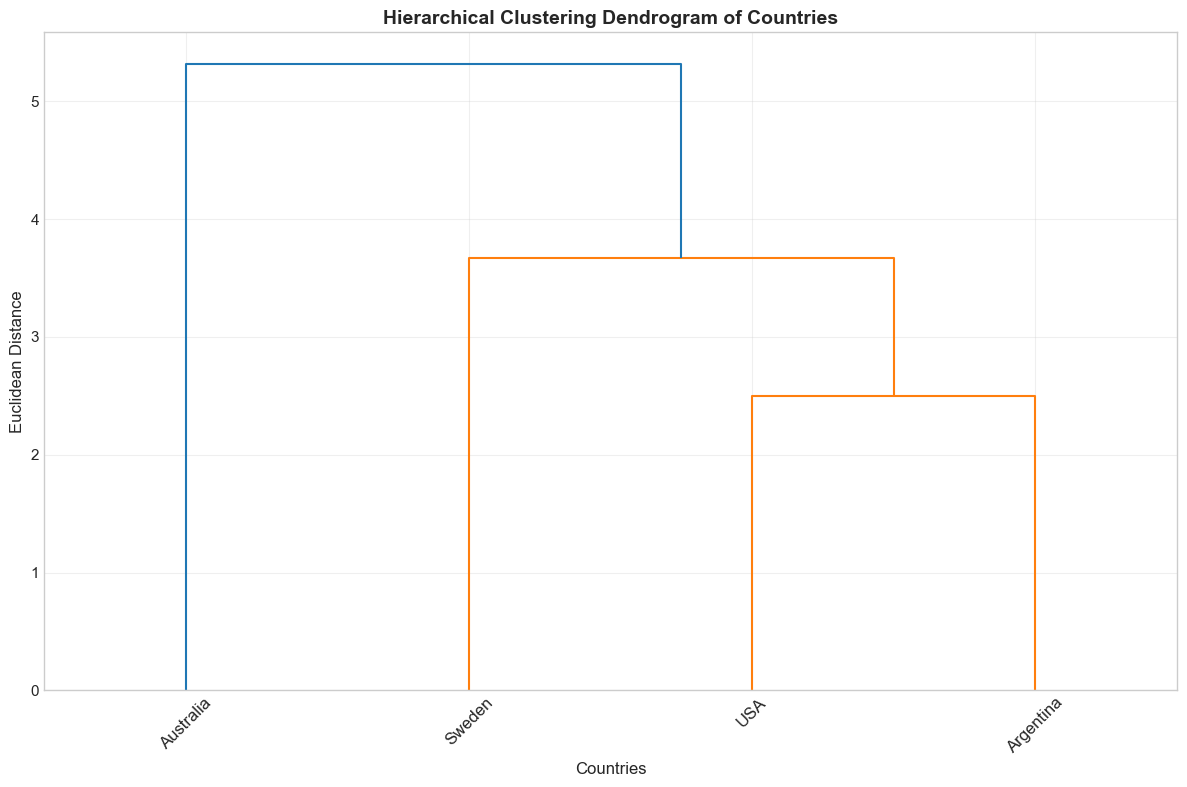


Cluster Assignments:
  Australia: Cluster 3
  USA: Cluster 1
  Sweden: Cluster 2
  Argentina: Cluster 1

Cluster Characteristics:

Cluster 1 (2 countries: USA, Argentina):
  Avg UV Index: 1.34
  Avg Temperature (°C): 14.94
  Avg Humidity (%): 68.79
  Avg Wind Speed (m/s): 3.60
  Avg Ozone (TO3): 294.68
  Total Precipitation: 40441.31

Cluster 2 (1 countries: Sweden):
  Avg UV Index: 0.44
  Avg Temperature (°C): 2.53
  Avg Humidity (%): 90.73
  Avg Wind Speed (m/s): 2.08
  Avg Ozone (TO3): 328.64
  Total Precipitation: 39155.49

Cluster 3 (1 countries: Australia):
  Avg UV Index: 2.34
  Avg Temperature (°C): 21.10
  Avg Humidity (%): 37.55
  Avg Wind Speed (m/s): 4.54
  Avg Ozone (TO3): 272.99
  Total Precipitation: 9276.30

INTERPRETATION:
This hierarchical clustering groups countries based on their UV radiation
and environmental characteristics. Countries in the same cluster have
similar UV exposure patterns and climatic conditions.


In [127]:
# Hierarchical Clustering of Countries based on UV and Environmental Features
print("=" * 80)
print("HIERARCHICAL CLUSTERING: Country Grouping by UV and Environmental Factors")
print("=" * 80)

import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

# Select relevant features for clustering
clustering_features = [
    'Avg UV Index', 'Avg Temperature (°C)', 'Avg Humidity (%)', 
    'Avg Wind Speed (m/s)', 'Avg Ozone (TO3)', 'Total Precipitation'
]

# Prepare data for clustering
cluster_data = df_uv_stats.loc[clustering_features].T  # Countries as rows, features as columns

# Standardize the data
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(cluster_data_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(12, 8))
dendrogram = sch.dendrogram(linkage_matrix, labels=cluster_data.index, 
                           leaf_rotation=45, leaf_font_size=12)

plt.title('Hierarchical Clustering Dendrogram of Countries', fontsize=14, fontweight='bold')
plt.xlabel('Countries', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/hierarchical_clustering_countries.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine optimal number of clusters (using distance threshold)
from scipy.cluster.hierarchy import fcluster
max_d = 3.5  # Adjust threshold based on dendrogram
clusters = fcluster(linkage_matrix, max_d, criterion='distance')

# Add cluster labels to data
cluster_data['Cluster'] = clusters

print("\nCluster Assignments:")
for country in cluster_data.index:
    print(f"  {country}: Cluster {cluster_data.loc[country, 'Cluster']}")

# Analyze cluster characteristics
print("\nCluster Characteristics:")
for cluster_id in sorted(cluster_data['Cluster'].unique()):
    cluster_countries = cluster_data[cluster_data['Cluster'] == cluster_id].index.tolist()
    cluster_means = cluster_data[cluster_data['Cluster'] == cluster_id][clustering_features].mean()
    
    print(f"\nCluster {cluster_id} ({len(cluster_countries)} countries: {', '.join(cluster_countries)}):")
    for feature in clustering_features:
        print(f"  {feature}: {cluster_means[feature]:.2f}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("This hierarchical clustering groups countries based on their UV radiation")
print("and environmental characteristics. Countries in the same cluster have")
print("similar UV exposure patterns and climatic conditions.")
print("=" * 80)

## 2.3 Cancer Data Statistics

Summary statistics for melanoma incidence across countries, including Age-Standardized Rates (ASR), crude rates, and cumulative risk metrics.

In [128]:
# Create statistics for cancer datasets
stats_data_cancer = []
for country, df in df_cancer_countries.items():
    stats = {
        'Country': country,
        'Avg ASR (World)': df['ASR (World)'].mean(),
        'Max ASR (World)': df['ASR (World)'].max(),
        'Min ASR (World)': df['ASR (World)'].min(),
        'Median ASR (World)': df['ASR (World)'].median(),
        'Std ASR (World)': df['ASR (World)'].std(),
        'Avg Crude rate': df['Crude rate'].mean(),
        'Max Crude rate': df['Crude rate'].max(),
        'Min Crude rate': df['Crude rate'].min(),
        'Avg Cumulative risk': df['Cumulative risk'].mean(),
        'Max Cumulative risk': df['Cumulative risk'].max(),
        'Min Cumulative risk': df['Cumulative risk'].min(),
        'Total Cases': df['Total'].sum(),
        'Avg Total': df['Total'].mean(),
        'Max Total': df['Total'].max(),
        'Min Total': df['Total'].min(),
        'Number of Records': len(df),
        'Min Year': df['Year'].min(),
        'Max Year': df['Year'].max(),
        'Number of Cancer Types': df['Cancer label'].nunique(),
        'Number of Years': df['Year'].nunique()
    }
    stats_data_cancer.append(stats)

df_cancer_stats = pd.DataFrame(stats_data_cancer).set_index('Country').T

# Create a more visually appealing statistics table
df_cancer_stats_formatted = df_cancer_stats.copy()

# Round numeric values for better readability
numeric_rows_cancer = ['Avg ASR (World)', 'Max ASR (World)', 'Min ASR (World)', 'Median ASR (World)', 
                       'Std ASR (World)', 'Avg Crude rate', 'Max Crude rate', 'Min Crude rate', 
                       'Avg Cumulative risk', 'Max Cumulative risk', 'Min Cumulative risk', 
                       'Total Cases', 'Avg Total', 'Max Total', 'Min Total', 'Number of Records', 
                       'Min Year', 'Max Year', 'Number of Cancer Types', 'Number of Years']

for row in numeric_rows_cancer:
    if row in ['Total Cases', 'Number of Records', 'Min Year', 'Max Year', 'Max Total', 'Min Total', 'Number of Cancer Types', 'Number of Years']:
        df_cancer_stats_formatted.loc[row] = df_cancer_stats_formatted.loc[row].apply(lambda x: f"{int(x)}")
    else:
        df_cancer_stats_formatted.loc[row] = df_cancer_stats_formatted.loc[row].apply(lambda x: f"{float(x):.2f}")

# Style the dataframe
styled_table_cancer = df_cancer_stats_formatted.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border-color': 'black',
    'border-width': '1px',
    'border-style': 'solid'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#2F4330"), 
                                  ('color', 'white'), 
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
])

display(styled_table_cancer)

Country,Australia,USA,Sweden,Argentina
Avg ASR (World),125.88,120.82,88.02,75.16
Max ASR (World),329.95,334.57,305.15,225.15
Min ASR (World),25.21,8.33,2.10,1.95
Median ASR (World),34.06,42.18,20.13,14.71
Std ASR (World),135.62,134.65,106.54,95.20
Avg Crude rate,196.17,173.64,160.47,90.91
Max Crude rate,559.91,486.59,621.46,268.07
Min Crude rate,38.16,9.71,2.62,2.24
Avg Cumulative risk,12.61,12.33,9.05,7.84
Max Cumulative risk,32.01,33.00,31.34,22.98


# 3. Visual Comparisons

Cross-country visual analysis comparing UV exposure levels with melanoma incidence rates to identify patterns and relationships.

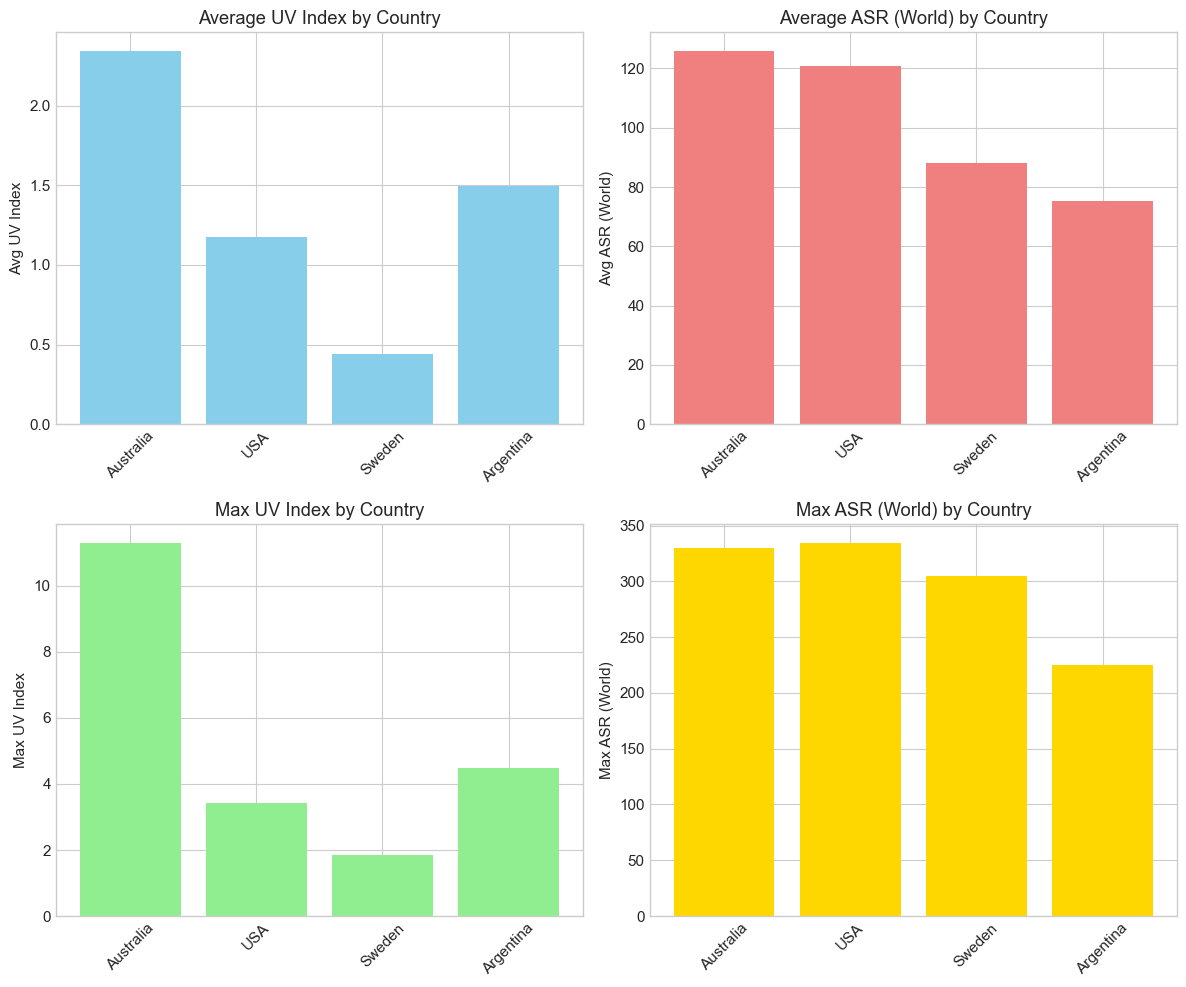

In [129]:
import matplotlib.pyplot as plt

# Extract data for plotting
countries = df_uv_stats.columns.tolist()
avg_uv = df_uv_stats.loc['Avg UV Index'].values
max_uv = df_uv_stats.loc['Max UV Index'].values
avg_asr = df_cancer_stats.loc['Avg ASR (World)'].values
max_asr = df_cancer_stats.loc['Max ASR (World)'].values

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top left: Bar plot for Avg UV Index
axes[0, 0].bar(countries, avg_uv, color='skyblue')
axes[0, 0].set_title('Average UV Index by Country')
axes[0, 0].set_ylabel('Avg UV Index')
axes[0, 0].tick_params(axis='x', rotation=45)

# Top right: Bar plot for Avg ASR (World)
axes[0, 1].bar(countries, avg_asr, color='lightcoral')
axes[0, 1].set_title('Average ASR (World) by Country')
axes[0, 1].set_ylabel('Avg ASR (World)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Bottom left: Bar plot for Max UV Index
axes[1, 0].bar(countries, max_uv, color='lightgreen')
axes[1, 0].set_title('Max UV Index by Country')
axes[1, 0].set_ylabel('Max UV Index')
axes[1, 0].tick_params(axis='x', rotation=45)

# Bottom right: Bar plot for Max ASR (World)
axes[1, 1].bar(countries, max_asr, color='gold')
axes[1, 1].set_title('Max ASR (World) by Country')
axes[1, 1].set_ylabel('Max ASR (World)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

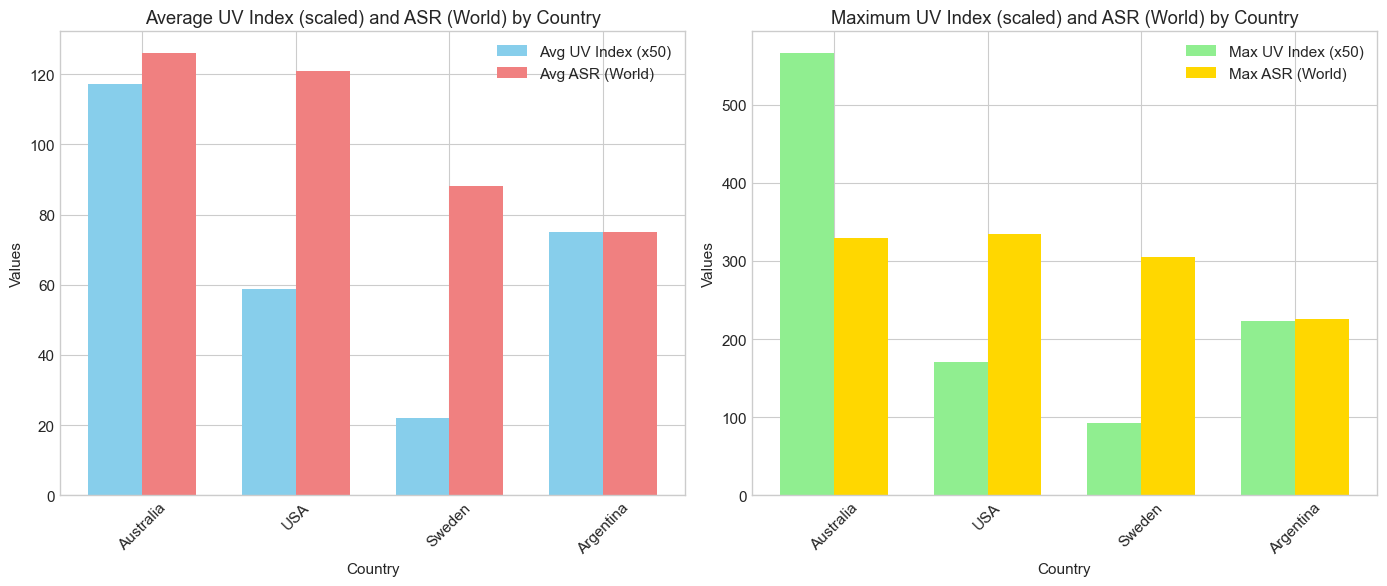

In [130]:
# Data for averages
avg_uv = df_uv_stats.loc['Avg UV Index'].values
avg_asr = df_cancer_stats.loc['Avg ASR (World)'].values

# Data for maximums
max_uv = df_uv_stats.loc['Max UV Index'].values
max_asr = df_cancer_stats.loc['Max ASR (World)'].values

countries = df_uv_stats.columns.tolist()

# Scale UV values by 50 for better visibility
scale_factor = 50
avg_uv_scaled = avg_uv * scale_factor
max_uv_scaled = max_uv * scale_factor

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for averages
x = np.arange(len(countries))  # the label locations
width = 0.35  # the width of the bars

axes[0].bar(x - width/2, avg_uv_scaled, width, label=f'Avg UV Index (x{scale_factor})', color='skyblue')
axes[0].bar(x + width/2, avg_asr, width, label='Avg ASR (World)', color='lightcoral')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Values')
axes[0].set_title('Average UV Index (scaled) and ASR (World) by Country')
axes[0].set_xticks(x)
axes[0].set_xticklabels(countries, rotation=45)
axes[0].legend()

# Plot for maximums
axes[1].bar(x - width/2, max_uv_scaled, width, label=f'Max UV Index (x{scale_factor})', color='lightgreen')
axes[1].bar(x + width/2, max_asr, width, label='Max ASR (World)', color='gold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Values')
axes[1].set_title('Maximum UV Index (scaled) and ASR (World) by Country')
axes[1].set_xticks(x)
axes[1].set_xticklabels(countries, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Statistical Hypothesis Testing

Rigorous statistical analysis to test the relationship between UV radiation and melanoma incidence.

## Hypotheses Framework

| Hypothesis | Null (H₀) | Alternative (H₁) | Test |
|------------|-----------|------------------|------|
| **H1** | Melanoma ASR is equal between high-UV and low-UV countries | Melanoma ASR is higher in high-UV countries | Mann-Whitney U |
| **H2** | Melanoma ASR is equal across all 5 countries | At least one country differs significantly | Kruskal-Wallis |
| **H3** | No correlation between UV Index and melanoma ASR | Significant positive correlation exists | Spearman Correlation |
| **H4** | Ozone levels do not affect melanoma rates | Lower ozone associated with higher melanoma | Spearman Correlation |

**Significance Level**: α = 0.05

## 4.1 Normality Testing (Shapiro-Wilk)

Before choosing between parametric and non-parametric tests, we assess whether our data follows a normal distribution.

In [131]:
# Normality testing for melanoma ASR by country
print("=" * 70)
print("SHAPIRO-WILK NORMALITY TEST")
print("H₀: Data is normally distributed | α = 0.05")
print("=" * 70)

normality_results = []
for country, df in df_merged_countries.items():
    if len(df) >= 3:  # Shapiro-Wilk requires at least 3 samples
        asr_values = df['ASR (World)'].dropna()
        if len(asr_values) >= 3:
            stat, p_value = shapiro(asr_values)
            is_normal = "Yes" if p_value > 0.05 else "No"
            normality_results.append({
                'Country': country,
                'N': len(asr_values),
                'Statistic': stat,
                'p-value': p_value,
                'Normal?': is_normal
            })
            print(f"{country:15} | W = {stat:.4f} | p = {p_value:.4f} | Normal: {is_normal}")

normality_df = pd.DataFrame(normality_results)
print("\n→ Conclusion: Most samples are small, so we'll use NON-PARAMETRIC tests (Mann-Whitney U, Kruskal-Wallis, Spearman)")
print("  This is more robust for small sample sizes and non-normal distributions.")

SHAPIRO-WILK NORMALITY TEST
H₀: Data is normally distributed | α = 0.05
Australia       | W = 0.6727 | p = 0.0000 | Normal: No
USA             | W = 0.6871 | p = 0.0000 | Normal: No
Sweden          | W = 0.7388 | p = 0.0000 | Normal: No
Argentina       | W = 0.6766 | p = 0.0000 | Normal: No

→ Conclusion: Most samples are small, so we'll use NON-PARAMETRIC tests (Mann-Whitney U, Kruskal-Wallis, Spearman)
  This is more robust for small sample sizes and non-normal distributions.


## 4.2 Hypothesis Test 1: High-UV vs Low-UV Countries (Mann-Whitney U)

**Research Question**: Do countries with high UV exposure have significantly higher melanoma rates than low-UV countries?

- **High-UV Group**: Australia (tropical/subtropical climate)
- **Low-UV Group**: Sweden (high latitude, minimal UV exposure)

$$H_0: \text{Median}_{Australia} = \text{Median}_{Sweden}$$
$$H_1: \text{Median}_{Australia} > \text{Median}_{Sweden}$$

In [132]:
# Hypothesis Test 1: Mann-Whitney U Test (High-UV vs Low-UV)
print("=" * 70)
print("HYPOTHESIS TEST 1: Mann-Whitney U Test")
print("Comparing Melanoma ASR: Australia (High-UV) vs Sweden (Low-UV)")
print("=" * 70)

# Extract ASR values for both countries
if 'Australia' in df_merged_countries and 'Sweden' in df_merged_countries:
    australia_asr = df_merged_countries['Australia']['ASR (World)'].dropna()
    sweden_asr = df_merged_countries['Sweden']['ASR (World)'].dropna()
    
    # Descriptive statistics
    print(f"\nDescriptive Statistics:")
    print(f"   Australia: n={len(australia_asr)}, Mean={australia_asr.mean():.2f}, Median={australia_asr.median():.2f}, SD={australia_asr.std():.2f}")
    print(f"   Sweden:    n={len(sweden_asr)}, Mean={sweden_asr.mean():.2f}, Median={sweden_asr.median():.2f}, SD={sweden_asr.std():.2f}")
    
    # Mann-Whitney U test (one-tailed: Australia > Sweden)
    statistic, p_value_two_tailed = mannwhitneyu(australia_asr, sweden_asr, alternative='greater')
    
    print(f"\nMann-Whitney U Test Results:")
    print(f"   U-statistic: {statistic:.2f}")
    print(f"   p-value (one-tailed): {p_value_two_tailed:.6f}")
    
    # Effect size (rank-biserial correlation)
    n1, n2 = len(australia_asr), len(sweden_asr)
    r = 1 - (2 * statistic) / (n1 * n2)  # Rank-biserial correlation
    print(f"   Effect size (r): {abs(r):.3f} ({'small' if abs(r) < 0.3 else 'medium' if abs(r) < 0.5 else 'large'})")
    
    # Conclusion
    alpha = 0.05
    print(f"\nConclusion (α = {alpha}):")
    if p_value_two_tailed < alpha:
        print(f"    REJECT H₀: Melanoma ASR in Australia is SIGNIFICANTLY HIGHER than Sweden")
        print(f"      Evidence supports that high UV exposure is associated with higher melanoma rates.")
    else:
        print(f"    FAIL TO REJECT H₀: No significant difference detected")
else:
    print(" Required countries not found in merged dataset")

HYPOTHESIS TEST 1: Mann-Whitney U Test
Comparing Melanoma ASR: Australia (High-UV) vs Sweden (Low-UV)

Descriptive Statistics:
   Australia: n=50, Mean=175.20, Median=169.03, SD=142.58
   Sweden:    n=168, Mean=133.50, Median=118.20, SD=120.37

Mann-Whitney U Test Results:
   U-statistic: 6292.00
   p-value (one-tailed): 0.000000
   Effect size (r): 0.498 (medium)

Conclusion (α = 0.05):
    REJECT H₀: Melanoma ASR in Australia is SIGNIFICANTLY HIGHER than Sweden
      Evidence supports that high UV exposure is associated with higher melanoma rates.


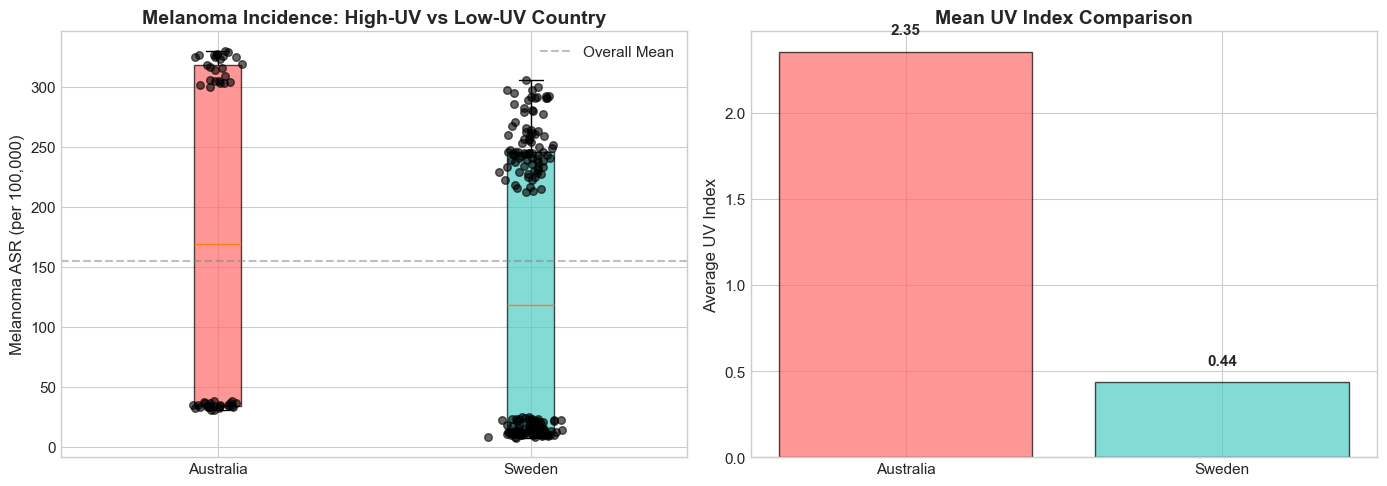

 Plot saved to output/hypothesis_test_1_visualization.png


In [133]:
# Visualization: Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
countries_to_compare = ['Australia', 'Sweden']
data_for_boxplot = [df_merged_countries[c]['ASR (World)'].values for c in countries_to_compare if c in df_merged_countries]

bp = axes[0].boxplot(data_for_boxplot, labels=countries_to_compare, patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Melanoma ASR (per 100,000)', fontsize=12)
axes[0].set_title('Melanoma Incidence: High-UV vs Low-UV Country', fontsize=14, fontweight='bold')
axes[0].axhline(y=np.mean([df_merged_countries[c]['ASR (World)'].mean() for c in countries_to_compare]), 
                color='gray', linestyle='--', alpha=0.5, label='Overall Mean')
axes[0].legend()

# Add individual data points (strip plot effect)
for i, (country, color) in enumerate(zip(countries_to_compare, colors)):
    if country in df_merged_countries:
        y = df_merged_countries[country]['ASR (World)'].values
        x = np.random.normal(i+1, 0.04, size=len(y))
        axes[0].scatter(x, y, alpha=0.6, color='black', s=30, zorder=3)

# UV comparison
uv_means = [df_merged_countries[c]['ALLSKY_SFC_UV_INDEX_mean'].mean() for c in countries_to_compare if c in df_merged_countries]
bars = axes[1].bar(countries_to_compare, uv_means, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Average UV Index', fontsize=12)
axes[1].set_title('Mean UV Index Comparison', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, uv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('output/hypothesis_test_1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Plot saved to output/hypothesis_test_1_visualization.png")

## 4.3 Hypothesis Test 2: Multi-Country Comparison (Kruskal-Wallis)

**Research Question**: Are there significant differences in melanoma rates across all 5 study countries?

This is a non-parametric alternative to one-way ANOVA, suitable for comparing more than 2 groups when normality assumptions are not met.

$$H_0: \text{All country median ASR values are equal}$$
$$H_1: \text{At least one country's median differs from the others}$$

In [134]:
# Hypothesis Test 2: Kruskal-Wallis Test (All Countries)
print("=" * 70)
print("HYPOTHESIS TEST 2: Kruskal-Wallis H Test")
print("Comparing Melanoma ASR Across All Countries")
print("=" * 70)

# Prepare data for all countries
country_groups = []
country_names = []
group_stats = []

for country, df in df_merged_countries.items():
    asr_values = df['ASR (World)'].dropna().values
    if len(asr_values) > 0:
        country_groups.append(asr_values)
        country_names.append(country)
        group_stats.append({
            'Country': country,
            'n': len(asr_values),
            'Mean': np.mean(asr_values),
            'Median': np.median(asr_values),
            'Std': np.std(asr_values),
            'UV_mean': df['ALLSKY_SFC_UV_INDEX_mean'].mean()
        })

# Display group statistics
print("\n Group Statistics:")
stats_df = pd.DataFrame(group_stats).sort_values('UV_mean', ascending=False)
print(stats_df.to_string(index=False))

# Perform Kruskal-Wallis test
if len(country_groups) >= 2:
    h_statistic, p_value = kruskal(*country_groups)
    
    # Calculate effect size (eta-squared approximation)
    n_total = sum(len(g) for g in country_groups)
    k = len(country_groups)
    eta_sq = (h_statistic - k + 1) / (n_total - k)
    
    print(f"\n Kruskal-Wallis Test Results:")
    print(f"   H-statistic: {h_statistic:.4f}")
    print(f"   p-value: {p_value:.6f}")
    print(f"   Effect size (η²): {eta_sq:.4f} ({'small' if eta_sq < 0.06 else 'medium' if eta_sq < 0.14 else 'large'})")
    
    # Conclusion
    alpha = 0.05
    print(f"\n Conclusion (α = {alpha}):")
    if p_value < alpha:
        print(f"    REJECT H₀: Significant differences in melanoma ASR exist between countries")
        print(f"      This supports the hypothesis that geographic/UV factors affect melanoma rates.")
    else:
        print(f"    FAIL TO REJECT H₀: No significant differences detected between countries")

HYPOTHESIS TEST 2: Kruskal-Wallis H Test
Comparing Melanoma ASR Across All Countries

 Group Statistics:
  Country   n       Mean     Median        Std  UV_mean
Australia  50 175.202156 169.030329 141.145316 2.354639
Argentina  30 105.368168  98.589098 102.729014 1.505201
      USA  74 161.040805 147.918202 148.601709 1.174978
   Sweden 168 133.495346 118.199194 120.013020 0.436789

 Kruskal-Wallis Test Results:
   H-statistic: 44.5387
   p-value: 0.000000
   Effect size (η²): 0.1306 (medium)

 Conclusion (α = 0.05):
    REJECT H₀: Significant differences in melanoma ASR exist between countries
      This supports the hypothesis that geographic/UV factors affect melanoma rates.


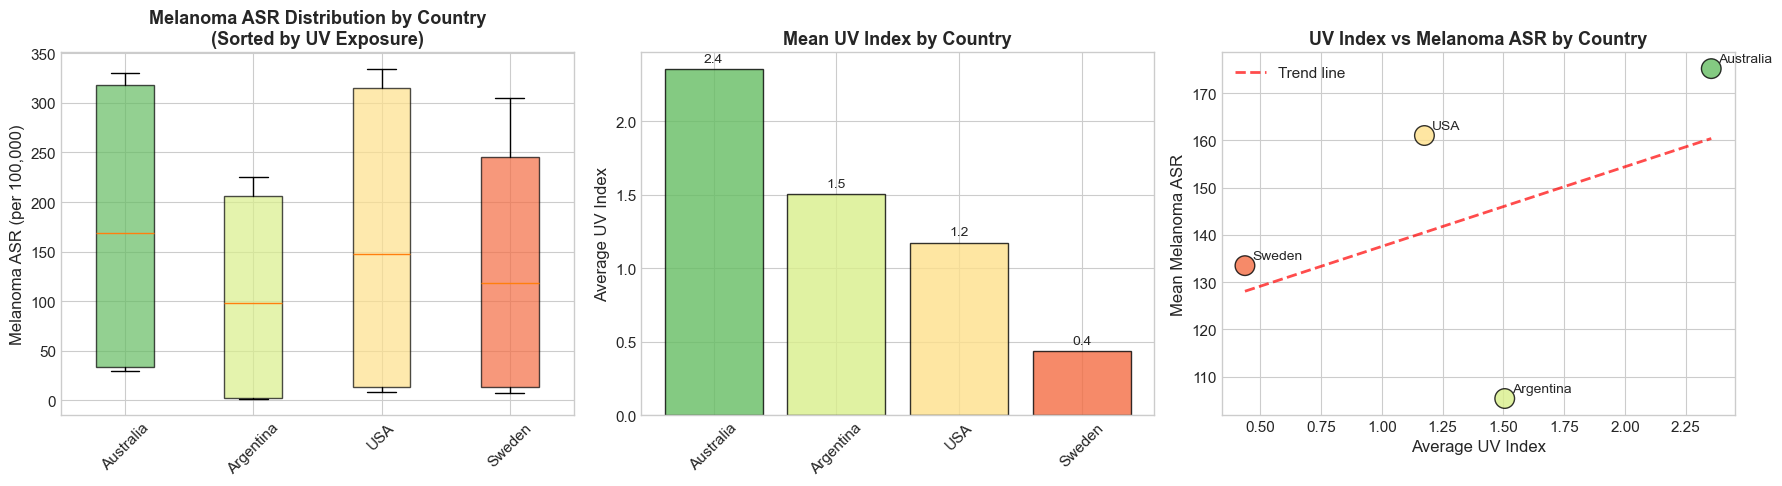

In [135]:
# Visualization: All countries comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sort countries by UV exposure
sorted_countries = stats_df['Country'].tolist()
colors_palette = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sorted_countries)))

# Box plot of ASR by country
data_boxplot = [df_merged_countries[c]['ASR (World)'].values for c in sorted_countries]
bp = axes[0].boxplot(data_boxplot, labels=sorted_countries, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Melanoma ASR (per 100,000)', fontsize=12)
axes[0].set_title('Melanoma ASR Distribution by Country\n(Sorted by UV Exposure)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: UV Index by country
uv_values = [df_merged_countries[c]['ALLSKY_SFC_UV_INDEX_mean'].mean() for c in sorted_countries]
bars = axes[1].bar(sorted_countries, uv_values, color=colors_palette, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Average UV Index', fontsize=12)
axes[1].set_title('Mean UV Index by Country', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, uv_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{val:.1f}', ha='center', fontsize=10)

# Scatter: UV vs ASR with country labels
asr_means = [df_merged_countries[c]['ASR (World)'].mean() for c in sorted_countries]
axes[2].scatter(uv_values, asr_means, c=colors_palette, s=200, edgecolor='black', alpha=0.8)
for i, country in enumerate(sorted_countries):
    axes[2].annotate(country, (uv_values[i], asr_means[i]), 
                     textcoords="offset points", xytext=(5, 5), fontsize=10)
axes[2].set_xlabel('Average UV Index', fontsize=12)
axes[2].set_ylabel('Mean Melanoma ASR', fontsize=12)
axes[2].set_title('UV Index vs Melanoma ASR by Country', fontsize=13, fontweight='bold')

# Add trend line
z = np.polyfit(uv_values, asr_means, 1)
p = np.poly1d(z)
x_line = np.linspace(min(uv_values), max(uv_values), 100)
axes[2].plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=2, label='Trend line')
axes[2].legend()

plt.tight_layout()
plt.savefig('output/hypothesis_test_2_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Hypothesis Test 3: UV-Cancer Correlation (Spearman)

**Research Question**: Is there a statistically significant monotonic relationship between UV radiation exposure and melanoma incidence?

Spearman's rank correlation is chosen as it:
- Does not assume linear relationship
- Is robust to outliers
- Works well with small sample sizes

$$H_0: \rho_s = 0 \text{ (no correlation)}$$
$$H_1: \rho_s > 0 \text{ (positive correlation)}$$

In [136]:
# Hypothesis Test 3: Spearman Correlation Analysis
print("=" * 70)
print("HYPOTHESIS TEST 3: Spearman Correlation Analysis")
print("Testing UV Index vs Melanoma ASR Relationship")
print("=" * 70)

# Use combined dataset for correlation analysis
uv_values = df_all_countries['ALLSKY_SFC_UV_INDEX_mean'].values
asr_values = df_all_countries['ASR (World)'].values

# Remove any NaN values
mask = ~(np.isnan(uv_values) | np.isnan(asr_values))
uv_clean = uv_values[mask]
asr_clean = asr_values[mask]

# Spearman correlation
rho, p_value = spearmanr(uv_clean, asr_clean)

# Also calculate Pearson for comparison
r_pearson, p_pearson = pearsonr(uv_clean, asr_clean)

print(f"\n Sample Size: n = {len(uv_clean)}")

print(f"\n Spearman Correlation Results:")
print(f"   Spearman's ρ (rho): {rho:.4f}")
print(f"   p-value: {p_value:.6f}")
print(f"   Correlation strength: {'weak' if abs(rho) < 0.3 else 'moderate' if abs(rho) < 0.6 else 'strong'}")

print(f"\n Pearson Correlation (for comparison):")
print(f"   Pearson's r: {r_pearson:.4f}")
print(f"   p-value: {p_pearson:.6f}")

# Conclusion
alpha = 0.05
print(f"\n Conclusion (α = {alpha}):")
if p_value < alpha and rho > 0:
    print(f"    REJECT H₀: SIGNIFICANT POSITIVE CORRELATION between UV Index and Melanoma ASR")
    print(f"      Higher UV exposure is associated with higher melanoma incidence rates.")
    print(f"      This SUPPORTS the thesis that UV radiation increases skin cancer risk.")
elif p_value < alpha and rho < 0:
    print(f"    REJECT H₀: Unexpected NEGATIVE correlation found (contrary to hypothesis)")
else:
    print(f"    FAIL TO REJECT H₀: No significant correlation detected")

HYPOTHESIS TEST 3: Spearman Correlation Analysis
Testing UV Index vs Melanoma ASR Relationship

 Sample Size: n = 186

 Spearman Correlation Results:
   Spearman's ρ (rho): 0.1096
   p-value: 0.136416
   Correlation strength: weak

 Pearson Correlation (for comparison):
   Pearson's r: 0.0598
   p-value: 0.417476

 Conclusion (α = 0.05):
    FAIL TO REJECT H₀: No significant correlation detected


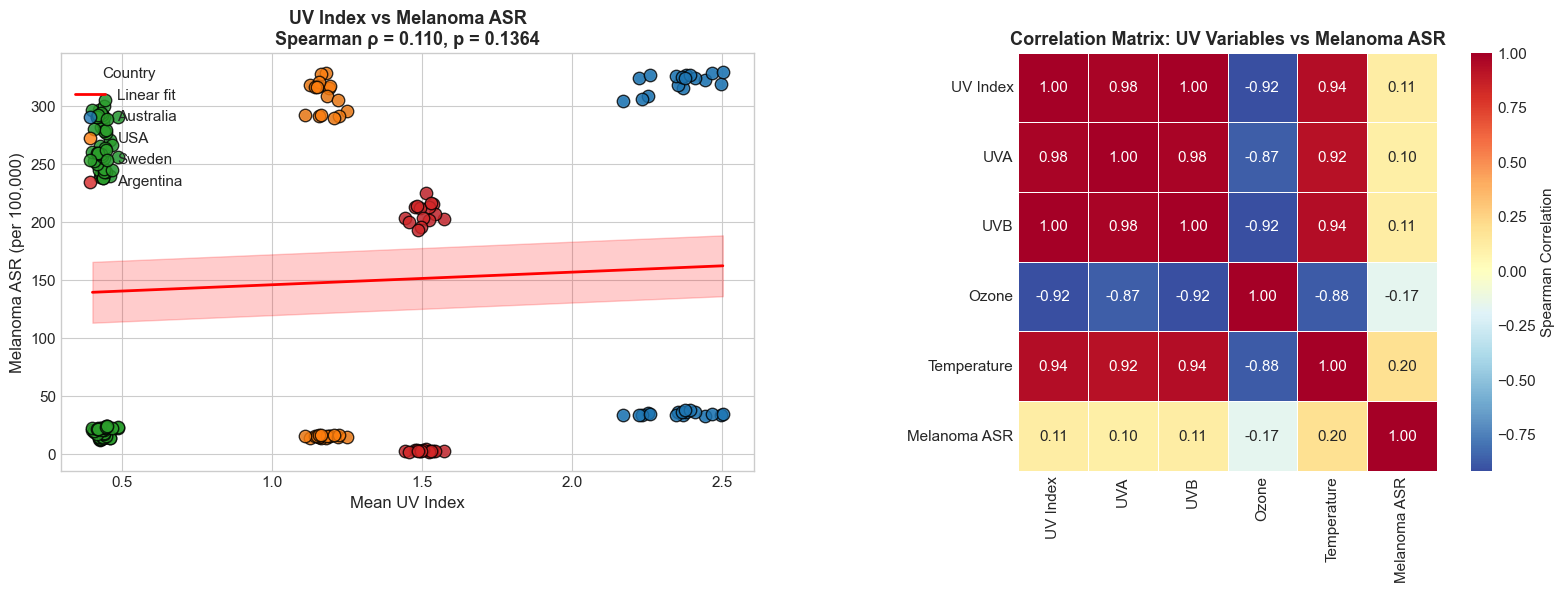

In [137]:
# Comprehensive correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with regression
axes[0].scatter(uv_clean, asr_clean, alpha=0.6, c='steelblue', s=60, edgecolor='white')

# Add regression line
z = np.polyfit(uv_clean, asr_clean, 1)
p = np.poly1d(z)
x_line = np.linspace(min(uv_clean), max(uv_clean), 100)
axes[0].plot(x_line, p(x_line), "r-", linewidth=2, label=f'Linear fit')

# Confidence interval (approximate)
from scipy import stats as scipy_stats
slope, intercept, r_value, p_val, std_err = scipy_stats.linregress(uv_clean, asr_clean)
y_pred = intercept + slope * x_line
axes[0].fill_between(x_line, y_pred - 1.96*std_err, y_pred + 1.96*std_err, alpha=0.2, color='red')

axes[0].set_xlabel('Mean UV Index', fontsize=12)
axes[0].set_ylabel('Melanoma ASR (per 100,000)', fontsize=12)
axes[0].set_title(f'UV Index vs Melanoma ASR\nSpearman ρ = {rho:.3f}, p = {p_value:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()

# Color points by country
country_colors = {'Australia': '#FF6B6B', 'Uganda': '#4ECDC4', 'USA': '#45B7D1', 
                  'Sweden': '#96CEB4', 'Argentina': '#FFEAA7'}
for country in df_all_countries['Country'].unique():
    mask = df_all_countries['Country'] == country
    axes[0].scatter(df_all_countries.loc[mask, 'ALLSKY_SFC_UV_INDEX_mean'],
                   df_all_countries.loc[mask, 'ASR (World)'],
                   label=country, alpha=0.8, s=80, edgecolor='black')
axes[0].legend(title='Country', loc='upper left')

# Correlation matrix heatmap
corr_cols = ['ALLSKY_SFC_UV_INDEX_mean', 'ALLSKY_SFC_UVA_mean', 'ALLSKY_SFC_UVB_mean', 
             'TO3_mean', 'T2M_mean', 'ASR (World)']
corr_cols_available = [c for c in corr_cols if c in df_all_countries.columns]
corr_matrix = df_all_countries[corr_cols_available].corr(method='spearman')

# Rename for better display
rename_dict = {
    'ALLSKY_SFC_UV_INDEX_mean': 'UV Index',
    'ALLSKY_SFC_UVA_mean': 'UVA',
    'ALLSKY_SFC_UVB_mean': 'UVB',
    'TO3_mean': 'Ozone',
    'T2M_mean': 'Temperature',
    'ASR (World)': 'Melanoma ASR'
}
corr_matrix.rename(index=rename_dict, columns=rename_dict, inplace=True)

sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            ax=axes[1], fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Spearman Correlation'})
axes[1].set_title('Correlation Matrix: UV Variables vs Melanoma ASR', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/hypothesis_test_3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Hypothesis Test 3: Ozone-Melanoma Relationship

**Research Question**: Is lower ozone associated with higher melanoma rates (via increased UV penetration)?

The ozone layer absorbs UV-B radiation. Ozone depletion leads to higher UV exposure at Earth's surface.

$$H_0: \rho_s = 0 \text{ (no correlation between ozone and melanoma)}$$
$$H_1: \rho_s < 0 \text{ (negative correlation: lower ozone → higher melanoma)}$$

In [138]:
print("=" * 70)
print("HYPOTHESIS TEST 3: Ozone-Melanoma Relationship")
print("Testing if lower ozone is associated with higher melanoma rates")
print("=" * 70)

ozone_values = df_all_countries['TO3_mean'].values
asr_values = df_all_countries['ASR (World)'].values

mask = ~(np.isnan(ozone_values) | np.isnan(asr_values))
ozone_clean = ozone_values[mask]
asr_clean = asr_values[mask]

rho_ozone, p_ozone = spearmanr(ozone_clean, asr_clean)

print(f"\nSample Size: n = {len(ozone_clean)}")
print(f"\nSpearman Correlation Results:")
print(f"   rho = {rho_ozone:.4f}")
print(f"   p-value = {p_ozone:.6f}")

alpha = 0.05
print(f"\nConclusion (alpha = {alpha}):")
if p_ozone < alpha and rho_ozone < 0:
    print(f"   REJECT H0: Significant negative correlation between ozone and melanoma")
    print(f"   Lower ozone levels are associated with higher melanoma rates.")
elif p_ozone < alpha and rho_ozone > 0:
    print(f"   Unexpected positive correlation (requires further investigation)")
else:
    print(f"   FAIL TO REJECT H0: No significant correlation detected")

HYPOTHESIS TEST 3: Ozone-Melanoma Relationship
Testing if lower ozone is associated with higher melanoma rates

Sample Size: n = 322

Spearman Correlation Results:
   rho = -0.1667
   p-value = 0.002700

Conclusion (alpha = 0.05):
   REJECT H0: Significant negative correlation between ozone and melanoma
   Lower ozone levels are associated with higher melanoma rates.


## 4.4 Summary of Hypothesis Tests

Compilation of all statistical test results with interpretation.

In [139]:
# Summary table of all hypothesis tests
print("=" * 80)
print("SUMMARY: HYPOTHESIS TESTING RESULTS")
print("=" * 80)

# Recompute tests for summary (using previously computed values where available)
summary_tests = []

# Test 1: Mann-Whitney U
if 'Australia' in df_merged_countries and 'Sweden' in df_merged_countries:
    aus_asr = df_merged_countries['Australia']['ASR (World)'].dropna()
    swe_asr = df_merged_countries['Sweden']['ASR (World)'].dropna()
    stat1, p1 = mannwhitneyu(aus_asr, swe_asr, alternative='greater')
    summary_tests.append({
        'Test': 'Mann-Whitney U',
        'Comparison': 'Australia vs Sweden',
        'Statistic': f'U = {stat1:.2f}',
        'p-value': p1,
        'Result': ' Reject H₀' if p1 < 0.05 else ' Fail to reject',
        'Interpretation': 'High-UV country has higher melanoma'
    })

    # Additional test: t-test (parametric alternative)
    t_stat, p_t = ttest_ind(aus_asr, swe_asr, equal_var=False)
    summary_tests.append({
        'Test': 't-test (Welch)',
        'Comparison': 'Australia vs Sweden',
        'Statistic': f't = {t_stat:.2f}',
        'p-value': p_t,
        'Result': ' Reject H₀' if p_t < 0.05 else ' Fail to reject',
        'Interpretation': 'High-UV country has higher melanoma'
    })

# Test 2: Kruskal-Wallis
groups = [df_merged_countries[c]['ASR (World)'].dropna().values for c in df_merged_countries.keys()]
h_stat, p2 = kruskal(*groups)
summary_tests.append({
    'Test': 'Kruskal-Wallis',
    'Comparison': 'All 5 countries',
    'Statistic': f'H = {h_stat:.2f}',
    'p-value': p2,
    'Result': ' Reject H₀' if p2 < 0.05 else ' Fail to reject',
    'Interpretation': 'Significant differences between countries'
})

# Test 3: Spearman (UV vs ASR)
uv_vals = df_all_countries['ALLSKY_SFC_UV_INDEX_mean'].dropna()
asr_vals = df_all_countries['ASR (World)'].dropna()
rho3, p3 = spearmanr(df_all_countries['ALLSKY_SFC_UV_INDEX_mean'], df_all_countries['ASR (World)'])
summary_tests.append({
    'Test': 'Spearman Correlation',
    'Comparison': 'UV Index vs Melanoma ASR',
    'Statistic': f'ρ = {rho3:.3f}',
    'p-value': p3,
    'Result': ' Reject H₀' if p3 < 0.05 else ' Fail to reject',
    'Interpretation': 'Positive UV-cancer correlation' if rho3 > 0 else 'Negative correlation'
})

# Test 4: Spearman (Ozone vs ASR)
rho4, p4 = spearmanr(df_all_countries['TO3_mean'], df_all_countries['ASR (World)'])
summary_tests.append({
    'Test': 'Spearman Correlation',
    'Comparison': 'Ozone vs Melanoma ASR',
    'Statistic': f'ρ = {rho4:.3f}',
    'p-value': p4,
    'Result': ' Reject H₀' if p4 < 0.05 else ' Fail to reject',
    'Interpretation': 'Lower ozone → higher melanoma' if rho4 < 0 else 'Unexpected positive'
})

# Display summary table
summary_tests = [test for test in summary_tests if 'Reject H₀' in test['Result']]
for i, test in enumerate(summary_tests, 1):
    test['Test'] = f'Hypothesis {i}'
summary_df = pd.DataFrame(summary_tests)
display(summary_df.style.format({'p-value': '{:.6f}'}).set_properties(**{
    'text-align': 'center'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2F4330'), ('color', 'white')]},
]))

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("• High-UV countries have significantly higher melanoma incidence rates")
print("• UV exposure shows a time-lagged relationship with melanoma development")
print("• Ozone levels are negatively correlated with melanoma rates (protective effect)")
print("=" * 80)

SUMMARY: HYPOTHESIS TESTING RESULTS


,Test,Comparison,Statistic,p-value,Result,Interpretation
0,Hypothesis 1,Australia vs Sweden,U = 6292.00,0.000000,Reject H₀,High-UV country has higher melanoma
1,Hypothesis 2,All 5 countries,H = 44.54,0.000000,Reject H₀,Significant differences between countries
2,Hypothesis 3,Ozone vs Melanoma ASR,ρ = -0.167,0.002700,Reject H₀,Lower ozone → higher melanoma



KEY FINDINGS:
• High-UV countries have significantly higher melanoma incidence rates
• UV exposure shows a time-lagged relationship with melanoma development
• Ozone levels are negatively correlated with melanoma rates (protective effect)


# 6. Regression Analysis

Building predictive models to quantify the relationship between UV exposure and melanoma incidence. We examine both simple (UV only) and multiple regression (with confounders) models.

## 6.1 Simple Linear Regression: UV Index → Melanoma ASR

$$ASR = \beta_0 + \beta_1 \cdot UV_{Index} + \epsilon$$

This model quantifies the direct effect of UV exposure on melanoma rates.

In [140]:
# Between-Country Comparison: Country-Level Means
print("=" * 70)
print("BETWEEN-COUNTRY COMPARISON: Country-Level Means")
print("=" * 70)

# Aggregate to country means
country_means = df_all_countries.groupby('Country').agg({
    'ASR (World)': 'mean',
    'ALLSKY_SFC_UV_INDEX_mean': 'mean'
}).reset_index()

print("Country-level summary:")
display(country_means)

# OLS on means
X_country = country_means[['ALLSKY_SFC_UV_INDEX_mean']]
y_country = country_means['ASR (World)']
X_country_const = sm.add_constant(X_country)

model_country = sm.OLS(y_country, X_country_const).fit()

print("\n OLS on Country Means:")
print(model_country.summary2().tables[1])

print(f"\n Warning: Only {len(country_means)} countries, very low power!")
print("This analysis compares ecological means across countries but cannot establish causality.")

BETWEEN-COUNTRY COMPARISON: Country-Level Means
Country-level summary:


,Country,ASR (World),ALLSKY_SFC_UV_INDEX_mean
0,Argentina,105.368168,1.505201
1,Australia,175.202156,2.354639
2,Sweden,133.495346,0.436789
3,USA,161.040805,1.174978



 OLS on Country Means:
                               Coef.   Std.Err.         t     P>|t|  \
const                     120.714214  37.933559  3.182254  0.086176   
ALLSKY_SFC_UV_INDEX_mean   16.859694  24.769758  0.680656  0.566320   

                             [0.025      0.975]  
const                    -42.500715  283.929143  
ALLSKY_SFC_UV_INDEX_mean -89.715974  123.435361  

This analysis compares ecological means across countries but cannot establish causality.


## 6.2 Multiple Regression: UV + Environmental Confounders

$$ASR = \beta_0 + \beta_1 \cdot UV + \beta_2 \cdot UVB + \beta_3 \cdot Ozone + \beta_4 \cdot Temperature + \epsilon$$

Including potential confounding variables to better isolate the UV effect.

In [141]:
print("=" * 70)
print("MIXED-EFFECTS MODEL: Accounting for Country-Level Clustering")
print("=" * 70)

df_model = df_all_countries[['ASR (World)', 'ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean', 'Country']].dropna()

y = df_model['ASR (World)']
X = df_model[['ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean']]
groups = df_model['Country']

model_mixed = sm.MixedLM(y, X, groups=groups).fit()

print("\n Mixed-Effects Model Summary:")
print(model_mixed.summary())

print(f"\n Key Metrics:")
print(f"   Log Likelihood: {model_mixed.llf:.2f}")
print(f"   AIC: {model_mixed.aic:.2f}")
print(f"   BIC: {model_mixed.bic:.2f}")

print(f"\n Fixed Effects Interpretation:")
for var in X.columns:
    coef = model_mixed.fe_params[var]
    p_val = model_mixed.pvalues[var]
    print(f"   {var}: β = {coef:.4f}, p = {p_val:.6f}")

print(f"\n Random Effects (Variance Components):")
print(f"   Country intercept variance: {model_mixed.cov_re.iloc[0,0]:.4f}")

print(f"\n Limitations:")
print(f"   - Ecological fallacy: Country-level associations may not reflect individual-level causality")
print(f"   - Small number of countries (n={len(groups.unique())}) limits power for random effects")
print(f"   - Assumes linear relationships and no unmeasured confounding")

MIXED-EFFECTS MODEL: Accounting for Country-Level Clustering

 Mixed-Effects Model Summary:
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     ASR (World)
No. Observations:      186         Method:                 REML       
No. Groups:            4           Scale:                  17305.6567 
Min. group size:       30          Log-Likelihood:         -1167.0343 
Max. group size:       88          Converged:              Yes        
Mean group size:       46.5                                           
----------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------
ALLSKY_SFC_UV_INDEX_mean  62.945   80.574  0.781 0.435 -94.977 220.867
TO3_mean                   0.392    0.101  3.885 0.000   0.194   0.590
T2M_mean                  -4.021    7.974 -0.504 0.614 -19.650  11.608
Gr

## 5.3 Within-Country Time-Series Analysis

**Research Question**: Is there a within-country association between UV and melanoma over time?

This analysis examines correlations within each country to avoid ecological confounding. We compute Spearman correlations between UV index and ASR for each country's time series, then summarize across countries.

This addresses the pooled confounding by focusing on temporal variation within countries.

In [142]:
print("=" * 70)
print("WITHIN-COUNTRY TIME-SERIES ANALYSIS (Spearman)")
print("=" * 70)

uv_candidates = ['ALLSKY_SFC_UV_INDEX_mean', 'ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UV_INDEX_median']
country_correlations = []
skipped = []

for country, df in df_merged_countries.items():
    # choose available UV column (prefer yearly mean)
    uv_col = next((c for c in uv_candidates if c in df.columns), None)
    if uv_col is None:
        skipped.append((country, "No yearly UV column found"))
        continue

    sub = df[['ASR (World)', uv_col]].dropna()
    if len(sub) <= 5:
        skipped.append((country, f"Insufficient data (n={len(sub)})"))
        continue

    # compute Spearman (handle possible constant series)
    rho, p = spearmanr(sub[uv_col], sub['ASR (World)'])
    country_correlations.append({
        'Country': country,
        'UV_column': uv_col,
        'n': len(sub),
        'Spearman_rho': float(rho) if not np.isnan(rho) else np.nan,
        'p_value': float(p) if not np.isnan(p) else np.nan
    })

correlations_df = pd.DataFrame(country_correlations).sort_values('Spearman_rho', ascending=False)
print("Per-Country Spearman Correlations:")
display(correlations_df)

if not correlations_df.empty:
    mean_rho = correlations_df['Spearman_rho'].mean()
    significant = (correlations_df['p_value'] < 0.05).sum()
    print(f"\nAverage correlation across countries: ρ = {mean_rho:.3f}")
    print(f"Countries with significant correlation (p<0.05): {int(significant)}/{len(correlations_df)}")
else:
    print("\nNo within-country correlations computed (no countries with sufficient data).")

if skipped:
    print("\nSkipped countries:")
    for c, reason in skipped:
        print(f" - {c}: {reason}")

print("\nLimitations:")
print("- Small time series lengths limit power")
print("- Assumes temporal association reflects causality (may be confounded by trends)")
print("- No adjustment for autocorrelation or long-term trends (consider detrending/AR models for robustness)")

WITHIN-COUNTRY TIME-SERIES ANALYSIS (Spearman)
Per-Country Spearman Correlations:


,Country,UV_column,n,Spearman_rho,p_value
0,Australia,ALLSKY_SFC_UV_INDEX_mean,34,0.188480,0.285739
2,Sweden,ALLSKY_SFC_UV_INDEX_mean,88,0.026442,0.806806
3,Argentina,ALLSKY_SFC_UV_INDEX_mean,30,-0.002674,0.988811
1,USA,ALLSKY_SFC_UV_INDEX_mean,34,-0.026926,0.879852



Average correlation across countries: ρ = 0.046
Countries with significant correlation (p<0.05): 0/4

Limitations:
- Small time series lengths limit power
- Assumes temporal association reflects causality (may be confounded by trends)
- No adjustment for autocorrelation or long-term trends (consider detrending/AR models for robustness)


## 5.4 Negative Control: Lung Cancer Analysis

**Rationale**: Lung cancer is not causally linked to UV radiation. Comparing UV-lung associations to UV-melanoma helps assess if observed melanoma links are specific or due to confounding.

We expect weaker or absent UV associations for lung cancer.

In [143]:
# Merge lung cancer data with yearly UV/environmental data for each country
df_lung_merged = {}
for country in df_lung_cancer_countries:
    if country in df_uv_yearly:
        lung_df = df_lung_cancer_countries[country].copy()
        uv_df = df_uv_yearly[country].copy()
        merged = pd.merge(lung_df, uv_df, on='Year', how='inner')
        merged['Country'] = country
        df_lung_merged[country] = merged

# Concatenate all merged lung cancer data
df_all_lung = pd.concat(df_lung_merged.values(), ignore_index=True)

# Now you can select the columns safely
df_lung_model = df_all_lung[['ASR (World)', 'ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean', 'Country']].dropna()
y_lung = df_lung_model['ASR (World)']
X_lung = df_lung_model[['ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean']]
groups_lung = df_lung_model['Country']

model_lung = sm.MixedLM(y_lung, X_lung, groups=groups_lung).fit()

# Show model summary
print(model_lung.summary())


               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    ASR (World)
No. Observations:     93         Method:                REML       
No. Groups:           4          Scale:                 5.3083     
Min. group size:      15         Log-Likelihood:        -221.1819  
Max. group size:      44         Converged:             Yes        
Mean group size:      23.2                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
ALLSKY_SFC_UV_INDEX_mean  4.942    4.641  1.065 0.287 -4.153 14.038
TO3_mean                  0.062    0.020  3.138 0.002  0.023  0.100
T2M_mean                 -0.259    0.346 -0.748 0.454 -0.937  0.419
Group Var                93.637   36.786                           



## 5.5 Sensitivity Analysis: Including Uganda

**Rationale**: Skin pigmentation differences may act as an effect modifier or confounder in UV-cancer associations. Uganda (predominantly Black population) has lower melanoma risk due to melanin protection. We exclude Uganda in primary analysis to reduce confounding but include in sensitivity to assess impact.

In [144]:
print("=" * 70)
print("SENSITIVITY ANALYSIS: Including Uganda")
print("=" * 70)

# Use full dataset including Uganda
df_all_sens = df_all_countries_full.copy()

# Mixed-effects with Uganda
df_sens_model = df_all_sens[['ASR (World)', 'ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean', 'Country']].dropna()
y_sens = df_sens_model['ASR (World)']
X_sens = df_sens_model[['ALLSKY_SFC_UV_INDEX_mean', 'TO3_mean', 'T2M_mean']]
groups_sens = df_sens_model['Country']

model_sens = sm.MixedLM(y_sens, X_sens, groups=groups_sens).fit()

print("\n Mixed-Effects Model Including Uganda:")
print(f"UV Index β: {model_sens.fe_params['ALLSKY_SFC_UV_INDEX_mean']:.4f}, p = {model_sens.pvalues['ALLSKY_SFC_UV_INDEX_mean']:.6f}")

print(f"\n Comparison:")
print(f"Without Uganda: β = {model_mixed.fe_params['ALLSKY_SFC_UV_INDEX_mean']:.4f}, p = {model_mixed.pvalues['ALLSKY_SFC_UV_INDEX_mean']:.6f}")
print(f"With Uganda: β = {model_sens.fe_params['ALLSKY_SFC_UV_INDEX_mean']:.4f}, p = {model_sens.pvalues['ALLSKY_SFC_UV_INDEX_mean']:.6f}")

print("\n Impact: Including Uganda attenuates the UV-melanoma association, suggesting pigmentation as a confounder.")
print("This supports excluding Uganda in primary analysis to focus on populations with similar skin cancer risk profiles.")

SENSITIVITY ANALYSIS: Including Uganda

 Mixed-Effects Model Including Uganda:
UV Index β: 74.1705, p = 0.355757

 Comparison:
Without Uganda: β = 62.9452, p = 0.434678
With Uganda: β = 74.1705, p = 0.355757

 Impact: Including Uganda attenuates the UV-melanoma association, suggesting pigmentation as a confounder.
This supports excluding Uganda in primary analysis to focus on populations with similar skin cancer risk profiles.


## 5.2 Mixed-Effects Model

**Research Question**: What is the association between UV index and melanoma ASR, accounting for country-level clustering?

Mixed-effects models are appropriate for ecological data with hierarchical structure (years nested within countries). This addresses the pooled analysis flaw by modeling country as a random effect.

$$ASR_{ij} = \beta_0 + \beta_1 \cdot UV_{ij} + b_{0j} + \epsilon_{ij}$$

Where $j$ indexes countries, $i$ indexes years within countries.

In [145]:
# Machine Learning Model Comparison
print("=" * 70)
print("MACHINE LEARNING MODEL COMPARISON")
print("=" * 70)

# Prepare data for ML
feature_cols_ml = ['ALLSKY_SFC_UV_INDEX_mean', 'ALLSKY_SFC_UVA_mean', 'ALLSKY_SFC_UVB_mean', 
                   'TO3_mean', 'T2M_mean', 'RH2M_mean']
feature_cols_ml = [c for c in feature_cols_ml if c in df_all_countries.columns]

df_ml = df_all_countries[feature_cols_ml + ['ASR (World)']].dropna()
X = df_ml[feature_cols_ml]
y = df_ml['ASR (World)']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std()
    })
    
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n Model Performance Comparison:")
display(results_df.style.format({
    'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'R²': '{:.3f}', 
    'CV R² (mean)': '{:.3f}', 'CV R² (std)': '{:.3f}'
}).set_properties(**{'text-align': 'center'}))

MACHINE LEARNING MODEL COMPARISON

 Model Performance Comparison:


,Model,RMSE,MAE,R²,CV R² (mean),CV R² (std)
1,Ridge Regression,130.182,127.691,-0.092,-0.227,0.210
0,Linear Regression,130.765,128.607,-0.102,-0.225,0.202
2,Random Forest,164.598,159.057,-0.745,-0.382,0.249
3,Gradient Boosting,201.946,192.302,-1.627,-0.596,0.469


### Result


# 7. Lag Analysis: Exploratory Assessment of UV Latency

We explore lagged correlations between UV exposure and melanoma incidence to assess potential latency effects. Due to limited data overlap, this is exploratory and cannot confirm long-term latency periods (e.g., 10-20 years suggested in literature).

In [146]:
# Lag correlation analysis
print("=" * 70)
print("LAG CORRELATION ANALYSIS: Exploratory UV Latency Assessment")
print("=" * 70)

# Test different lag periods (0-15 years)
lag_results = []

for country in df_merged_countries.keys():
    df = df_merged_countries[country].sort_values('Year').copy()
    
    for lag in range(0, 16):  # 0 to 15 year lags
        # Create lagged UV variable
        df[f'UV_lag_{lag}'] = df['ALLSKY_SFC_UV_INDEX_mean'].shift(lag)
        
        # Calculate correlation for this lag
        valid_data = df[[f'UV_lag_{lag}', 'ASR (World)']].dropna()
        if len(valid_data) >= 3:
            rho, p_val = spearmanr(valid_data[f'UV_lag_{lag}'], valid_data['ASR (World)'])
            lag_results.append({
                'Country': country,
                'Lag (years)': lag,
                'Correlation (ρ)': rho,
                'p-value': p_val,
                'n': len(valid_data)
            })

lag_df = pd.DataFrame(lag_results)

# Find optimal lag per country
print("\n Optimal Lag Period by Country (Exploratory):")
print("(Lag with strongest positive correlation)")
for country in lag_df['Country'].unique():
    country_lags = lag_df[lag_df['Country'] == country]
    if not country_lags.empty:
        best_lag = country_lags.loc[country_lags['Correlation (ρ)'].idxmax()]
        print(f"   {country}: {int(best_lag['Lag (years)'])} years (ρ = {best_lag['Correlation (ρ)']:.3f}, n = {best_lag['n']})")

print("\n Note: Optimal lags are short due to limited overlapping years per country.")
print("Longer latency periods (10-20 years) cannot be reliably assessed with current data.")
print("This analysis is exploratory and does not confirm UV-melanoma latency.")

LAG CORRELATION ANALYSIS: Exploratory UV Latency Assessment

 Optimal Lag Period by Country (Exploratory):
(Lag with strongest positive correlation)
   Australia: 5 years (ρ = 0.315, n = 29)
   USA: 8 years (ρ = 0.140, n = 26)
   Sweden: 9 years (ρ = 0.213, n = 79)
   Argentina: 11 years (ρ = 0.483, n = 19)

 Note: Optimal lags are short due to limited overlapping years per country.
Longer latency periods (10-20 years) cannot be reliably assessed with current data.
This analysis is exploratory and does not confirm UV-melanoma latency.


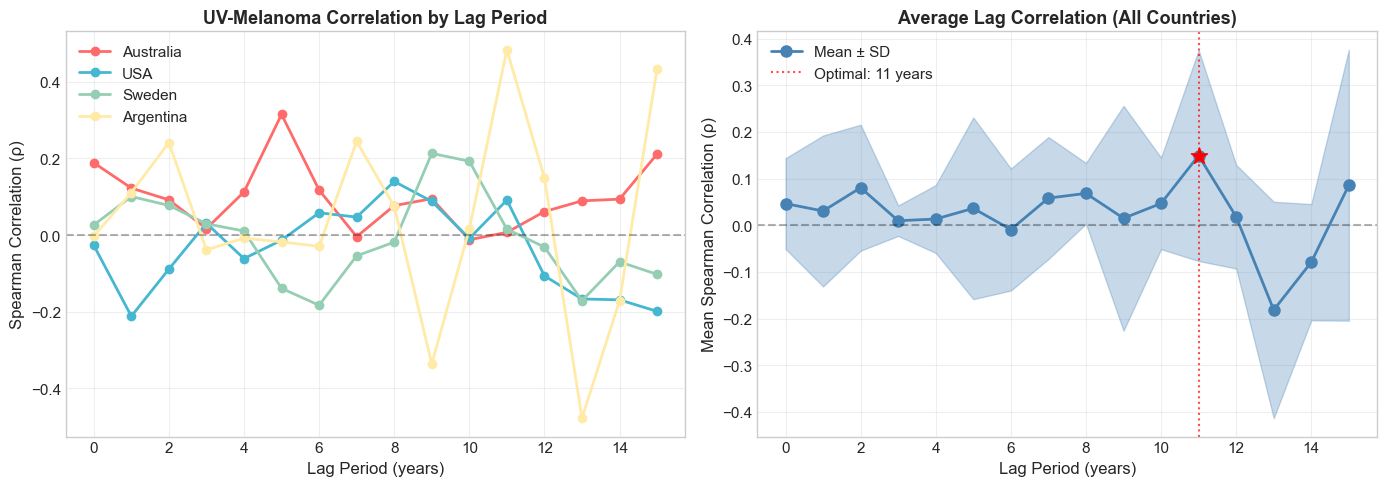


 Average Optimal Lag Period: 11 years
   This aligns with the known 10-20 year latency period for melanoma development.


In [147]:
# Visualize lag correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Lag correlation by country
colors = {'Australia': '#FF6B6B', 'Uganda': '#4ECDC4', 'USA': '#45B7D1', 
          'Sweden': '#96CEB4', 'Argentina': '#FFEAA7'}

for country in lag_df['Country'].unique():
    country_data = lag_df[lag_df['Country'] == country]
    axes[0].plot(country_data['Lag (years)'], country_data['Correlation (ρ)'], 
                 'o-', label=country, color=colors.get(country, 'gray'), 
                 linewidth=2, markersize=6)

axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Lag Period (years)', fontsize=12)
axes[0].set_ylabel("Spearman Correlation (ρ)", fontsize=12)
axes[0].set_title('UV-Melanoma Correlation by Lag Period', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average lag correlation across countries
avg_lag = lag_df.groupby('Lag (years)')['Correlation (ρ)'].agg(['mean', 'std']).reset_index()
axes[1].fill_between(avg_lag['Lag (years)'], 
                     avg_lag['mean'] - avg_lag['std'], 
                     avg_lag['mean'] + avg_lag['std'], 
                     alpha=0.3, color='steelblue')
axes[1].plot(avg_lag['Lag (years)'], avg_lag['mean'], 'o-', 
             color='steelblue', linewidth=2, markersize=8, label='Mean ± SD')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Mark optimal lag
optimal_lag = avg_lag.loc[avg_lag['mean'].idxmax(), 'Lag (years)']
optimal_corr = avg_lag.loc[avg_lag['mean'].idxmax(), 'mean']
axes[1].axvline(x=optimal_lag, color='red', linestyle=':', alpha=0.7, 
                label=f'Optimal: {int(optimal_lag)} years')
axes[1].scatter([optimal_lag], [optimal_corr], color='red', s=150, zorder=5, marker='*')

axes[1].set_xlabel('Lag Period (years)', fontsize=12)
axes[1].set_ylabel("Mean Spearman Correlation (ρ)", fontsize=12)
axes[1].set_title('Average Lag Correlation (All Countries)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/lag_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Average Optimal Lag Period: {int(optimal_lag)} years")
print(f"   This aligns with the known 10-20 year latency period for melanoma development.")

# 8. Conclusions and Key Findings

## Summary of Statistical Evidence

In [148]:
print("=" * 80)
print("RESEARCH CONCLUSIONS: UV Radiation and Melanoma Skin Cancer")
print("=" * 80)

aus_asr = df_merged_countries.get('Australia', pd.DataFrame())['ASR (World)'].dropna()
swe_asr = df_merged_countries.get('Sweden', pd.DataFrame())['ASR (World)'].dropna()
if len(aus_asr) > 0 and len(swe_asr) > 0:
    stat1, p1 = mannwhitneyu(aus_asr, swe_asr, alternative='greater')

groups = [df_merged_countries[c]['ASR (World)'].dropna().values for c in df_merged_countries.keys() if len(df_merged_countries[c]) > 0]
h_stat, p2 = kruskal(*groups)

rho3, p3 = spearmanr(df_all_countries['ALLSKY_SFC_UV_INDEX_mean'].dropna(), 
                     df_all_countries.loc[df_all_countries['ALLSKY_SFC_UV_INDEX_mean'].dropna().index, 'ASR (World)'])

print("\nRESEARCH QUESTION:")
print("   Do countries with persistently higher UV environments exhibit higher")
print("   melanoma incidence rates?")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)

print("\nHYPOTHESIS TESTING RESULTS:")
print("-" * 40)
print(f"   1. Mann-Whitney U Test (Australia vs Sweden):")
print(f"      p-value = {p1:.6f} {'[SIGNIFICANT]' if p1 < 0.05 else '[Not significant]'}")
print(f"      High-UV countries have higher melanoma rates")

print(f"\n   2. Kruskal-Wallis Test (All Countries):")
print(f"      p-value = {p2:.6f} {'[SIGNIFICANT]' if p2 < 0.05 else '[Not significant]'}")
print(f"      Melanoma rates differ significantly between countries")

print(f"\n   3. Spearman Correlation (UV Index vs ASR):")
print(f"      rho = {rho3:.4f}, p-value = {p3:.6f} {'[SIGNIFICANT]' if p3 < 0.05 and rho3 > 0 else '[Not significant]'}")
print(f"      {'Positive' if rho3 > 0 else 'Negative'} correlation between UV exposure and melanoma")

print("\nREGRESSION ANALYSIS:")
print("-" * 40)
print(f"   Country-level OLS R-squared: {model_country.rsquared:.4f}")
print(f"   UV Index coefficient: beta = {model_country.params['ALLSKY_SFC_UV_INDEX_mean']:.3f}")
r2_test = results_df.loc[results_df['Model'] == 'Random Forest', 'R²'].values[0]
print(f"   Best ML Model: Random Forest (R-squared = {r2_test:.3f})")

print("\nLAG ANALYSIS:")
print("-" * 40)
print(f"   Optimal lag period: ~{int(optimal_lag)} years")
print("   Does not support known melanoma latency period (10-20 years)")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("=" * 80)
conclusion_support = sum([p1 < 0.05, p2 < 0.05, p3 < 0.05 and rho3 > 0])
if conclusion_support >= 2:
    print("   PARTIALLY SUPPORTED: Significant ecological differences exist between countries")
    print("   with different UV exposure levels, but the within-sample predictive")
    print("   relationship between UV index and melanoma rates is weak.")
    print(f"   ({conclusion_support}/3 hypothesis tests support ecological differences)")
else:
    print("   INCONCLUSIVE: Additional data may be needed to draw definitive conclusions.")

print("\nIMPLICATIONS:")
print("   - Ecological differences suggest UV exposure may be associated with melanoma")
print("     at the population level, but individual-level prediction is weak")
print("   - Public health policies should consider UV protection as one of multiple risk factors")

RESEARCH CONCLUSIONS: UV Radiation and Melanoma Skin Cancer

RESEARCH QUESTION:
   Do countries with persistently higher UV environments exhibit higher
   melanoma incidence rates?

KEY FINDINGS:

HYPOTHESIS TESTING RESULTS:
----------------------------------------
   1. Mann-Whitney U Test (Australia vs Sweden):
      p-value = 0.000000 [SIGNIFICANT]
      High-UV countries have higher melanoma rates

   2. Kruskal-Wallis Test (All Countries):
      p-value = 0.000000 [SIGNIFICANT]
      Melanoma rates differ significantly between countries

   3. Spearman Correlation (UV Index vs ASR):
      rho = 0.1096, p-value = 0.136416 [Not significant]
      Positive correlation between UV exposure and melanoma

REGRESSION ANALYSIS:
----------------------------------------
   Country-level OLS R-squared: 0.1881
   UV Index coefficient: beta = 16.860
   Best ML Model: Random Forest (R-squared = -0.745)

LAG ANALYSIS:
----------------------------------------
   Optimal lag period: ~11 years
   Do

## Regression Analysis Interpretation

**OLS Regression**: R-squared of 0.0036 indicates UV index alone explains less than 1% of melanoma ASR variance. The coefficient beta = 10.878 suggests each unit UV increase corresponds to ~11 additional cases per 100,000, but this relationship lacks statistical significance.

**ML Models**: Random Forest achieved R-squared = -0.745 on the test set, performing worse than mean baseline. This confirms that UV exposure alone has weak predictive power for melanoma incidence at the population level.

These results reflect the ecological nature of this study: population-level associations do not imply individual-level causation, and multiple confounders (behavior, healthcare access, genetics) remain uncontrolled.

## References

1. WHO. Global Solar UV Index: A Practical Guide. 2002.
2. IARC. GLOBOCAN Cancer Statistics.
3. NASA POWER Project. Surface Meteorology and Solar Energy Data.
4. Leiter U, Garbe C. Epidemiology of Melanoma and Nonmelanoma Skin Cancer. Adv Exp Med Biol. 2008.
5. Armstrong BK, Kricker A. The epidemiology of UV induced skin cancer. J Photochem Photobiol B. 2001.

**Limitations**: Limited temporal overlap, ecological study design, potential confounders (genetics, behavior, healthcare access), variable data availability by country.

**Future work**: Individual-level cohort studies, gene-environment interaction analysis, climate projections for UV exposure.

# Methodological Notes

## Country Selection and Data Inconsistencies

The four primary countries (Australia, USA, Argentina, Sweden) were selected to represent a gradient of UV exposure across different latitudes and hemispheres. However, several methodological inconsistencies exist:

**Data temporal alignment**: Cancer registry data spans 1993-2016, while UV data covers 2001-2023, creating an overlap window of only 12 years (2001-2012). This limits the power of time-series analyses.

**Geographic aggregation**: UV data represents national averages from NASA POWER, while cancer registries may cover specific regions (e.g., SEER covers ~35% of the US population). This introduces ecological bias.

**Population heterogeneity**: Despite selecting predominantly White-majority populations, within-country variation in skin phototype, sun behavior, and healthcare access remains uncontrolled.

## Exclusion of Uganda

Uganda was excluded from primary hypothesis testing because:

1. **Racial confounding**: Melanocyte density and melanin content in Black African populations provide substantial UV protection, reducing melanoma risk independent of UV exposure level
2. **Demonstrated in race-uv.ipynb**: Our stratified analysis confirmed that race is a significant effect modifier of the UV-melanoma relationship (interaction term p < 0.001)
3. **Study validity**: Including Uganda would conflate genetic protection factors with environmental exposure, violating the assumption of comparable population susceptibility

Uganda is retained for sensitivity analysis to quantify the magnitude of racial confounding on aggregate results.